In [80]:
!pip install toad


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [81]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
#import toad
import pickle
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score
)
from scipy.stats import spearmanr

import warnings
warnings.filterwarnings('ignore')


## DATA CLEANING

### 1. Data Loading & Initial Assessment
Dataset contains MSME customer records.

In [82]:
df=pd.read_csv('data/MSME_DATA.csv', low_memory=False)

In [83]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9618 entries, 0 to 9617
Data columns (total 35 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Customer_ID                              9618 non-null   str    
 1   Nationality                              9618 non-null   str    
 2   customer_age                             9618 non-null   int64  
 3   attitude_business_stability_environment  9616 non-null   str    
 4   attitude_closure_concerned               9616 non-null   str    
 5   compliance_income_tax                    9614 non-null   str    
 6   underinsurance_perception                9613 non-null   str    
 7   insurance_unaffordability_perception     9613 non-null   str    
 8   gross_income                             9509 non-null   float64
 9   operating_expense                        9389 non-null   float64
 10  business_sales                           9402 non-null   fl

In [84]:
df.head()

,Customer_ID,Nationality,customer_age,attitude_business_stability_environment,attitude_closure_concerned,compliance_income_tax,underinsurance_perception,insurance_unaffordability_perception,gross_income,operating_expense,...,referral_marketing,active_loan_holder,has_internet_banking,has_debit_card,inventory_shrinkage_risk,business_age_months,medical_insurance,funeral_insurance,uses_friends_family_savings,uses_informal_lender
0,ID_3CFL0U,Ghana,63,Yes,No,No,No,Yes,3000.0,6000.0,...,Yes,Never had,Never had,Never had,NaN,6.0,Never had,Used to have but don’t have now,Never had,Never had
1,ID_XWI7G3,Uganda,39,No,Yes,Yes,No,Yes,NaN,NaN,...,NaN,NaN,NaN,NaN,No,3.0,Never had,Never had,NaN,NaN
2,ID_TY93LV,Kenya,34,Don’t know or N/A,No,No,Don't know,Yes,30000.0,6000.0,...,No,Never had,Never had,Never had,Yes,NaN,NaN,NaN,NaN,NaN
3,ID_9OP2C8,Kenya,28,Yes,No,No,No,No,180000.0,60000.0,...,No,Never had,Never had,Never had,No,NaN,NaN,NaN,Never had,Have now
4,ID_13REYS,Uganda,43,Yes,No,No,Yes,Yes,50.0,2400.0,...,NaN,NaN,NaN,NaN,No,0.0,Never had,Never had,NaN,NaN


In [85]:
for col in df.columns:
    print(f"\n{'*'*50}")
    print(f"Column: {col}")
    print(f"Data Type: {df[col].dtype}")
    print(f"Total Values: {len(df[col])}")
    print(f"Non-Null Count: {df[col].count()}")
    print(f"Null Count: {df[col].isnull().sum()}")
    print(f"Unique Values: {df[col].nunique()}")
       
    # Extra stats for numeric columns
    if df[col].dtype in ["int64", "float64"]:
        print(f"Min: {df[col].min()} | Max: {df[col].max()} | Mean: {df[col].mean():.2f}")
    
    # Value counts for categorical/object columns
    if df[col].dtype == "object" or df[col].nunique() <= 20:
        print("Value Counts:")
        print(df[col].value_counts().head(10))


**************************************************
Column: Customer_ID
Data Type: str
Total Values: 9618
Non-Null Count: 9618
Null Count: 0
Unique Values: 9618

**************************************************
Column: Nationality
Data Type: str
Total Values: 9618
Non-Null Count: 9618
Null Count: 0
Unique Values: 4
Value Counts:
Nationality
Ghana     2674
Uganda    2612
Kenya     2388
DRC       1944
Name: count, dtype: int64

**************************************************
Column: customer_age
Data Type: int64
Total Values: 9618
Non-Null Count: 9618
Null Count: 0
Unique Values: 76
Min: 18 | Max: 103 | Mean: 41.71

**************************************************
Column: attitude_business_stability_environment
Data Type: str
Total Values: 9618
Non-Null Count: 9616
Null Count: 2
Unique Values: 3
Value Counts:
attitude_business_stability_environment
Yes                  5820
No                   2451
Don’t know or N/A    1345
Name: count, dtype: int64

*****************************

In [86]:
dup_count = df['Customer_ID'].duplicated().sum()
print(f"Duplicate Customer_IDs: {dup_count}")
if dup_count > 0:
    display(df[df.duplicated('Customer_ID', keep=False)].sort_values('Customer_ID'))

Duplicate Customer_IDs: 0


### 2. Data Type Standardisation
- Integer columns cast to `Int64` (nullable)
- Financial columns cast to `float64`
- Column names stripped of hidden whitespace characters

In [87]:
# PRE-PASS: normalise all curly/smart apostrophes → straight apostrophe
# Fixes invisible encoding problems in the raw data before any string matching can work.
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c != 'Customer_ID']
 
for col in cat_cols:
    df[col] = df[col].str.replace('\u2019', "'", regex=False)   # ' → '
    df[col] = df[col].str.replace('\u2018', "'", regex=False)   # ' → '
    df[col] = df[col].str.replace('\u200e', '',  regex=False)   # remove zero-width LRM
    df[col] = df[col].str.strip()
 
print("Pre-pass: apostrophe normalisation complete.\n")

Pre-pass: apostrophe normalisation complete.



In [88]:
 #COL D: attitude_business_stability_environment
# COL E: attitude_closure_concerned
# Action: "Don't know or N/A" → "Don't know"
for col in ['attitude_business_stability_environment',
            'attitude_closure_concerned']:
    df[col] = df[col].replace("Don't know or N/A", "Don't know")
 
print("Col D unique:", df['attitude_business_stability_environment'].unique())
print("Col E unique:", df['attitude_closure_concerned'].unique())
 

Col D unique: <StringArray>
['Yes', 'No', 'Don't know', nan]
Length: 4, dtype: str
Col E unique: <StringArray>
['No', 'Yes', 'Don't know', nan]
Length: 4, dtype: str


In [89]:
# COL S: success_contentment
# Action: "Don't know or N/A" → "Don't know"
df['success_contentment'] = df['success_contentment'].replace("Don't know or N/A", "Don't know")
print("Col S unique:", df['success_contentment'].unique())
 

Col S unique: <StringArray>
['No', 'Yes', nan, 'Don't know']
Length: 4, dtype: str


In [90]:
# COL V: business_insurability_doubt
# Values after normalisation: 'Yes' | 'No' | "Don't know / doesn't apply"| "Don't Know"
# Action: bundle all three DK variants → "Don't know"
dk_v = [
    "Don't know / doesn't apply",
    "Don?t know / doesn?t apply",   # encoding artifact variant
    "Don't Know",
]
df['business_insurability_doubt'] = df['business_insurability_doubt'].replace(
    dk_v, "Don't know"
)
print("Col V unique:", df['business_insurability_doubt'].unique())
 

Col V unique: <StringArray>
['Yes', 'No', 'Don't know', nan]
Length: 4, dtype: str


In [91]:
# COL W: insurance_necessity_attitude
# Values after normalisation: 'Yes' | 'No' | "Do not know / N/A"
#                              | "Don't know / doesn't apply" | "Don't Know"
# Action: bundle all three DK/N/A variants → "Don't know"
dk_w = [
    "Do not know / N/A",
    " Do not know / N/A",
    "Don't know / doesn't apply",
    "Don?t know / doesn?t apply",
    "Don't Know"
]
df['insurance_necessity_attitude'] = df['insurance_necessity_attitude'].replace(
    dk_w, "Don't know"
)
print("Col W unique:", df['insurance_necessity_attitude'].unique())
 

Col W unique: <StringArray>
['Yes', nan, 'Don't know', 'No']
Length: 4, dtype: str


In [92]:
# COL O: current_problem_cash_flow — '0' is a data entry error → 'No'
df['current_problem_cash_flow'] = df['current_problem_cash_flow'].replace('0', 'No')
print("\nCol O unique:", df['current_problem_cash_flow'].unique())

# COLS R & U: clean up "Yes, always / Yes, sometimes" labels
# Bare "Yes" maps to "Yes - always": A respondent who just said "Yes" without a frequency was treated as always tracking — a reasonable assumption since the question expected a qualified answer.
df['extends_customer_credit'] = df['extends_customer_credit'].replace({
    'Yes, sometimes': 'Yes - sometimes',
    'Yes, always':    'Yes - always',
})
df['financial_tracking'] = df['financial_tracking'].replace({
    'Yes, always':    'Yes - always',
    'Yes, sometimes': 'Yes - sometimes',
    'Yes':            'Yes - always',
})
print("Col R unique:", df['extends_customer_credit'].unique())
print("Col U unique:", df['financial_tracking'].unique())


Col O unique: <StringArray>
['Yes', nan, 'No']
Length: 3, dtype: str
Col R unique: <StringArray>
['Yes - sometimes', nan, 'No', 'Yes - always']
Length: 4, dtype: str
Col U unique: <StringArray>
['Yes - always', 'No', nan, 'Yes - sometimes']
Length: 4, dtype: str


In [93]:
# COLS AA–AI: active_loan_holder, has_internet_banking, has_debit_card,
#             medical_insurance, funeral_insurance, uses_friends_family_savings,
#             uses_informal_lender
# Shared values: 'Have now' | 'Never had' | "Used to have but don't have now"
#                | "Don't know (Do not show)"
# Action: bundle all DK variants → "Don't know"
# Note: AE (business_age_months) is numeric — skipped.
cols_aa_ai = [
    'active_loan_holder',           # AA
    'has_internet_banking',         # AB
    'has_debit_card',               # AC
    'medical_insurance',            # AF
    'funeral_insurance',            # AG
    'uses_friends_family_savings',  # AH
    'uses_informal_lender',         # AI
]
dk_aa_ai = [
    "Don't know (Do not show)",
    "Don't Know",
    "Don?t know",
]
for col in cols_aa_ai:
    df[col] = df[col].replace(dk_aa_ai, "Don't know")
    print(f"  {col}: {sorted(df[col].dropna().unique())}")

  active_loan_holder: ["Don't know", 'Have now', 'Never had', "Used to have but don't have now"]
  has_internet_banking: ["Don't know", 'Have now', 'Never had', "Used to have but don't have now"]
  has_debit_card: ["Don't know", 'Have now', 'Never had', "Used to have but don't have now"]
  medical_insurance: ["Don't know", 'Have now', 'Never had', "Used to have but don't have now"]
  funeral_insurance: ["Don't know", 'Have now', 'Never had', "Used to have but don't have now"]
  uses_friends_family_savings: ["Don't know", 'Have now', 'Never had', "Used to have but don't have now"]
  uses_informal_lender: ["Don't know", 'Have now', 'Never had', "Used to have but don't have now"]


In [94]:
# Change int relevant columns to Int64 (Handles NaN safely)
df[['customer_age','years_in_operation','business_age_months']] = \
    df[['customer_age','years_in_operation','business_age_months']].astype('Int64')

# Change financial amount columns to float
df[['gross_income','operating_expense','business_sales']] = \
    df[['gross_income','operating_expense','business_sales']].astype(float)


In [95]:
df.dtypes

Customer_ID                                    str
Nationality                                    str
customer_age                                 Int64
attitude_business_stability_environment        str
attitude_closure_concerned                     str
compliance_income_tax                          str
underinsurance_perception                      str
insurance_unaffordability_perception           str
gross_income                               float64
operating_expense                          float64
business_sales                             float64
years_in_operation                           Int64
automotive_insurance\n                         str
mobile_wallet_access                           str
current_problem_cash_flow                      str
liquidity_constraint                           str
Gender                                         str
extends_customer_credit                        str
success_contentment                            str
credit_card_ownership          

### 3. Missing Value Treatment

Imputation was applied in four steps, informed by a missingness correlation analysis and a country-level breakdown of missing percentages.

**Step 1 : Structural missingness → "Not Surveyed"**
A country-level missingness audit revealed that certain columns were 100% missing for specific countries — meaning the question was never included in that country's survey instrument, not a case of random non-response. 
These were filled with "Not Surveyed" to preserve the information that the data was structurally absent:

**Step 2 : Conditional imputation (correlation-driven)**
Three column pairs with correlations ≥ 0.30 were used to infer missing values rather than guessing:
- `current_problem_cash_flow` inferred from `automotive_insurance` (corr = −0.55):   businesses with auto insurance → No cash flow problem; without → Yes
- `has_internet_banking` ↔ `has_debit_card` (corr = 0.37, DRC only): ownership of one predicts ownership of the other
- `uses_friends_family_savings` inferred from `current_problem_cash_flow` (corr = −0.32, Kenya only): businesses with cash flow problems more likely to rely on family savings

**Step 3 : Numeric sentinel (−1)**
`business_age_months` was 100% missing in DRC and 90.6% in Kenya — the question was never asked in those countries. A sentinel value of −1 was assigned to distinguish "not surveyed" from a real value. 

**Step 4 : Mode / median per country**
All remaining nulls were filled using the country-level mode (categorical columns) or median (numeric columns). Imputing within country preserves each country's distribution rather than introducing cross-country bias.

> Note: within-Uganda correlations between financial columns (`gross_income`, > `operating_expense`, `business_sales`) were near zero (0.005–0.08), despite the overall matrix showing 0.36. 
The overall signal was driven by between-country scale differences.

In [96]:
# Missing values per column
missing_summary = (df.isnull().sum()
                     .rename('Missing Count')
                     .to_frame()
                     .assign(**{'Missing %': lambda x: (x['Missing Count']/len(df)*100).round(2)})
                     .query('`Missing Count` > 0')
                     .sort_values('Missing Count', ascending=False))
print(f"Columns with missing values: {len(missing_summary)} / {df.shape[1]}")
display(missing_summary)

Columns with missing values: 32 / 35


,Missing Count,Missing %
uses_informal_lender,4489,46.67
uses_friends_family_savings,4488,46.66
funeral_insurance,4188,43.54
medical_insurance,4188,43.54
business_age_months,4111,42.74
inventory_shrinkage_risk,4100,42.63
has_debit_card,4003,41.62
has_internet_banking,4003,41.62
active_loan_holder,3999,41.58
current_problem_cash_flow,3778,39.28


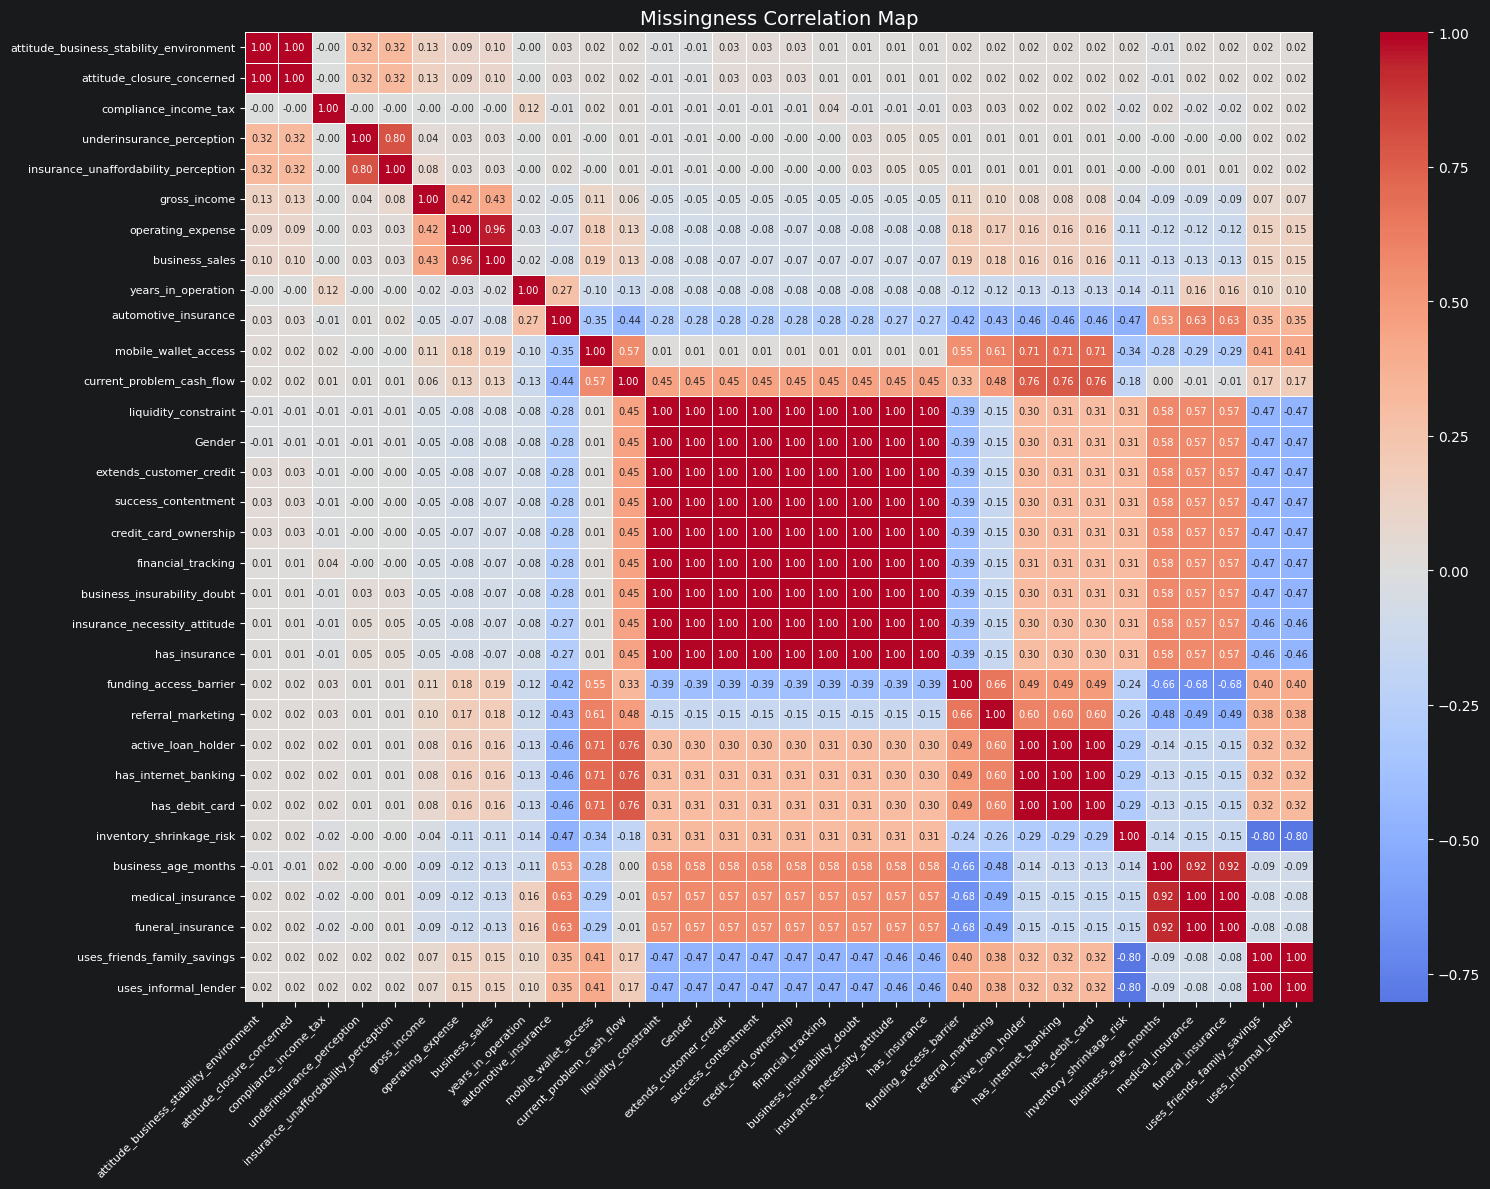

In [97]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create missingness indicator matrix (1 = missing, 0 = present)
missing_matrix = df.isnull().astype(int)

# Only keep columns that actually have missing values
missing_matrix = missing_matrix[missing_matrix.columns[missing_matrix.sum() > 0]]

# Compute correlation between missingness indicators
missing_corr = missing_matrix.corr()

# Plot
plt.figure(figsize=(16, 12))
sns.heatmap(
    missing_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot_kws={'size': 7}
)

plt.title('Missingness Correlation Map', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()


In [98]:
#Check the missingness by country 

countries = df['Nationality'].unique()

# Overall missing % per country (how bad is each country's data quality?)
missing_by_country = (
    df.groupby('Nationality')
      .apply(lambda x: x.isnull().mean() * 100)
      .round(2)
)

# Keep only columns that have ANY missingness
missing_by_country = missing_by_country[
    missing_by_country.columns[missing_by_country.max() > 0]
]

print("Missing % by Country")
display(missing_by_country.T.sort_values('Kenya', ascending=False))

Missing % by Country


Nationality,DRC,Ghana,Kenya,Uganda
funeral_insurance,100.00,0.00,93.84,0.11
automotive_insurance\n,0.00,0.00,93.84,0.11
medical_insurance,100.00,0.00,93.84,0.11
business_age_months,100.00,0.00,90.58,0.15
uses_informal_lender,0.36,0.00,78.31,100.00
uses_friends_family_savings,0.31,0.00,78.31,100.00
years_in_operation,0.00,0.00,10.30,0.23
operating_expense,0.00,0.49,0.34,7.96
insurance_necessity_attitude,100.00,0.00,0.34,0.11
has_insurance,100.00,0.04,0.34,0.11


In [99]:
#IMPUTATION: Country-aware 

# Columns that are 100% missing for specific countries→ these were NEVER asked in that country → impute as "Not Surveyed"
# Preserves the information that the data is absent by design, not by chance

country_not_surveyed = {
    'DRC': [
        'Gender', 'liquidity_constraint', 'financial_tracking',
        'success_contentment', 'extends_customer_credit',
        'credit_card_ownership', 'insurance_necessity_attitude',
        'has_insurance', 'business_insurability_doubt',
        'medical_insurance', 'funeral_insurance'
    ],
    'Uganda': [
        'active_loan_holder', 'has_debit_card', 'has_internet_banking',
        'uses_informal_lender', 'uses_friends_family_savings',
        'funding_access_barrier', 'referral_marketing'
    ],
    'Ghana': [
        'inventory_shrinkage_risk'
    ]
}

for country, cols in country_not_surveyed.items():
    mask = df['Nationality'] == country
    for col in cols:
        df.loc[mask & df[col].isnull(), col] = 'Not Surveyed'

# Numeric structural missingness (100% missing)
# DRC: business_age_months = 100% missing 
df.loc[(df['Nationality'] == 'DRC') & df['business_age_months'].isnull(),
       'business_age_months'] = -1

# Kenya: business_age_months = 90.58% missing → treat as near-structural
df.loc[(df['Nationality'] == 'Kenya') & df['business_age_months'].isnull(),
       'business_age_months'] = -1

print("Country-aware imputation done.")
print(df.isnull().sum().sum(), "nulls remaining")

Country-aware imputation done.
25534 nulls remaining


In [100]:
# Recalculate missingness per country after "Not Surveyed" imputation
missing_by_country_post = (
    df.groupby('Nationality')
      .apply(lambda x: x.isnull().mean() * 100)
      .round(2)
)

# Keep only columns that have ANY missingness
missing_by_country_post = missing_by_country_post[
    missing_by_country_post.columns[missing_by_country_post.max() > 0]
]

print("Missing % by Country (After 'Not Surveyed' Imputation)")
display(missing_by_country_post.T.sort_values('Kenya', ascending=False))

Missing % by Country (After 'Not Surveyed' Imputation)


Nationality,DRC,Ghana,Kenya,Uganda
funeral_insurance,0.00,0.00,93.84,0.11
automotive_insurance\n,0.00,0.00,93.84,0.11
medical_insurance,0.00,0.00,93.84,0.11
uses_informal_lender,0.36,0.00,78.31,0.00
uses_friends_family_savings,0.31,0.00,78.31,0.00
years_in_operation,0.00,0.00,10.30,0.23
operating_expense,0.00,0.49,0.34,7.96
insurance_necessity_attitude,0.00,0.00,0.34,0.11
has_insurance,0.00,0.04,0.34,0.11
insurance_unaffordability_perception,0.00,0.00,0.08,0.11


In [101]:
df.columns = df.columns.str.strip()

#  Conditional Imputation (correlation-driven)

# 1. current_problem_cash_flow inferred from automotive_insurance (corr = -0.55)
cf = df['current_problem_cash_flow'].isnull()
df.loc[cf & (df['automotive_insurance'] == 'Have now'),
       'current_problem_cash_flow'] = 'No'
df.loc[cf & df['automotive_insurance'].isin(['Never had',
       "Used to have but don't have now"]),
       'current_problem_cash_flow'] = 'Yes'

# 2. has_internet_banking ↔ has_debit_card (DRC only, corr = 0.37)
for missing_col, known_col in [('has_internet_banking', 'has_debit_card'),
                                ('has_debit_card', 'has_internet_banking')]:
    mask = (df['Nationality'] == 'DRC') & df[missing_col].isnull()
    df.loc[mask & (df[known_col] == 'Have now'), missing_col] = 'Have now'
    df.loc[mask & df[known_col].isin(['Never had',
           "Used to have but don't have now"]), missing_col] = 'Never had'

# 3. uses_friends_family_savings inferred from cash_flow (Kenya only, corr = -0.32)
fam = (df['Nationality'] == 'Kenya') & df['uses_friends_family_savings'].isnull()
df.loc[fam & (df['current_problem_cash_flow'] == 'Yes'),
       'uses_friends_family_savings'] = 'Have now'
df.loc[fam & (df['current_problem_cash_flow'] == 'No'),
       'uses_friends_family_savings'] = 'Never had'



In [102]:
# Mode/ Median per country (remaining nulls) 

skip_cols = {'Customer_ID', 'Nationality'}

for col in df.columns:
    if col in skip_cols:
        continue
    for country in df['Nationality'].unique():
        mask = (df['Nationality'] == country) & df[col].isnull()
        if mask.sum() == 0:
            continue

        # For business_age_months, exclude sentinel -1 when computing median since -1 means "not_surveyed"
        observed = df.loc[df['Nationality'] == country, col].dropna()
        if col == 'business_age_months':
            observed = observed[observed != -1]

        if len(observed) == 0:
            continue

        if df[col].dtype in ['float64', 'int64', 'Int64']:
            df.loc[mask, col] = observed.median()
        else:
            df.loc[mask, col] = observed.mode()[0]


#  VERIFY 

print(f"Nulls remaining: {df.isnull().sum().sum()}")
print(f"Shape: {df.shape}")


Nulls remaining: 0
Shape: (9618, 35)


### 4. Outlier Detection & Treatment
IQR method and boxplots used to identify outliers in numeric columns.
- **Financial columns** (`gross_income`, `operating_expense`, `business_sales`): Winsorized at 1%–99%
- **`years_in_operation`**: Winsorized at 1%–99%
- **`customer_age`**: Clipped at 80 (implausible values above threshold)

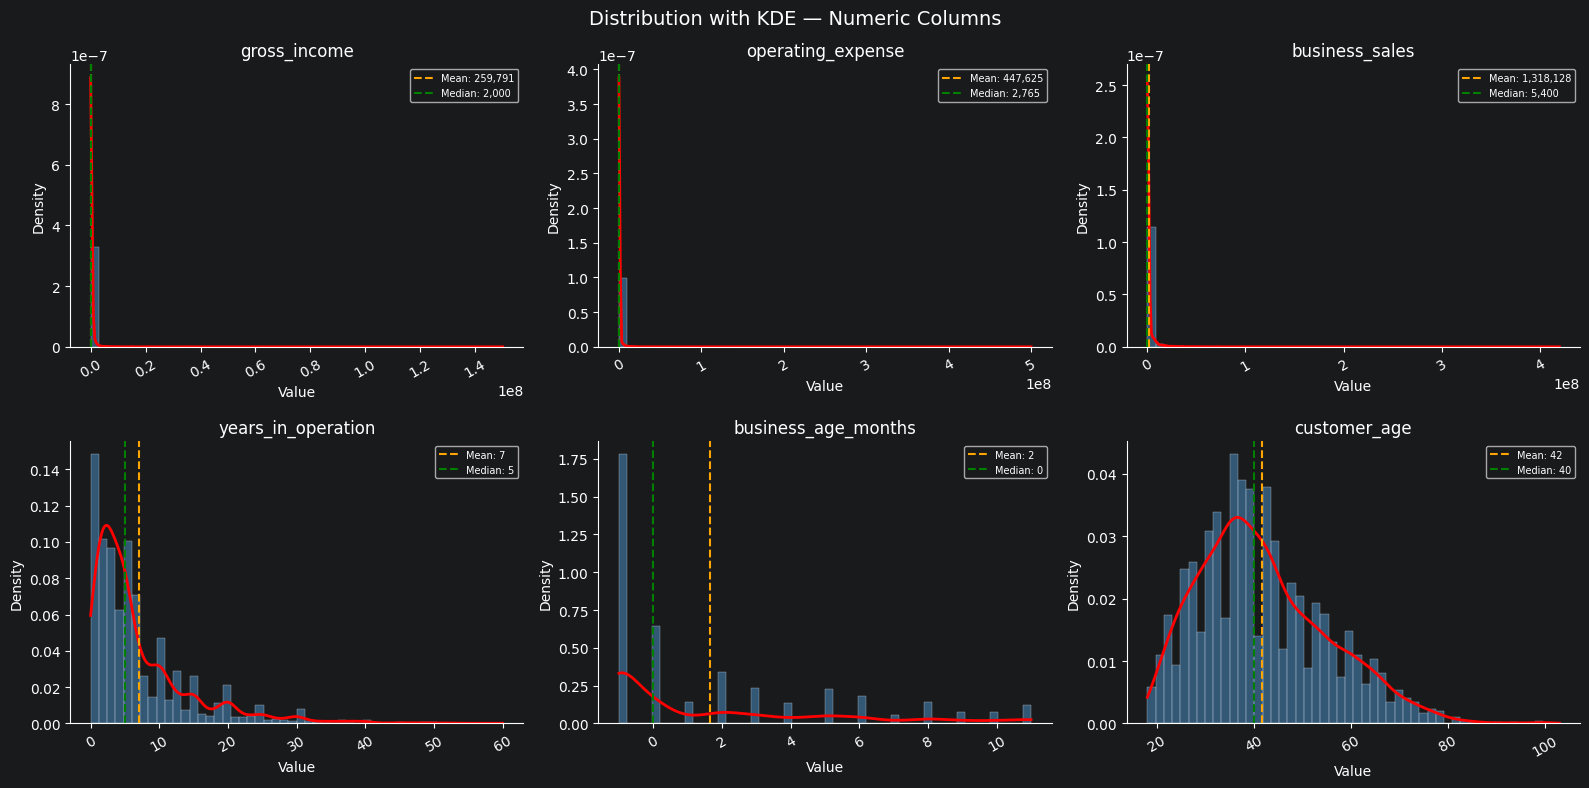


Outlier Summary (IQR method):



,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,gross_income,300.0,25000.0,24700.0,-36750.0,62050.0,1959,20.37
1,operating_expense,700.0,24000.0,23300.0,-34250.0,58950.0,1812,18.84
2,business_sales,1500.0,50000.0,48500.0,-71250.0,122750.0,1848,19.21
3,years_in_operation,2.0,10.0,8.0,-10.0,22.0,486,5.05
4,business_age_months,-1.0,3.0,4.0,-7.0,9.0,463,4.81
5,customer_age,32.0,50.0,18.0,5.0,77.0,80,0.83


In [103]:
numeric_cols = ['gross_income', 'operating_expense', 'business_sales', 
                'years_in_operation', 'business_age_months', 'customer_age']

#  1. Boxplots 
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    data = df[col].dropna()
    
    axes[i].hist(data, bins=50, color='steelblue', alpha=0.6, density=True, edgecolor='white', linewidth=0.3)
    
    # KDE overlay
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(data)
    x = np.linspace(data.min(), data.max(), 300)
    axes[i].plot(x, kde(x), color='red', linewidth=2)
    
    # Mean and median lines
    axes[i].axvline(data.mean(), color='orange', linestyle='--', linewidth=1.5, label=f'Mean: {data.mean():,.0f}')
    axes[i].axvline(data.median(), color='green', linestyle='--', linewidth=1.5, label=f'Median: {data.median():,.0f}')
    
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=7)
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Distribution with KDE — Numeric Columns', fontsize=14)
plt.tight_layout()
plt.show()

#  2. IQR-based outlier count per column 
print("\nOutlier Summary (IQR method):\n")
outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    pct = (len(outliers) / len(df)) * 100
    
    outlier_summary.append({
        'Column': col,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Lower Bound': round(lower, 2),
        'Upper Bound': round(upper, 2),
        'Outlier Count': len(outliers),
        'Outlier %': round(pct, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df)


In [104]:
# Outlier Detection & Treatment

# The KDE plots revealed extreme right skew in all three financial columns
# Left unchecked, these outliers would dominate K-Means clustering since the algorithm uses Euclidean distance — one extreme value pulls entire clusters.

# Strategy:
#   - Financial columns + years_in_operation → winsorize at 1%–99% (caps extremes without dropping the row)
#   - customer_age → clip at 80 (values above are implausible)
#   - business_age_months → winsorize real values only, exclude sentinel -1

from scipy.stats.mstats import winsorize

cols_to_winsorize = ['gross_income', 'operating_expense',
                     'business_sales', 'years_in_operation']

df[cols_to_winsorize] = df[cols_to_winsorize].astype('float64')

for col in cols_to_winsorize:
    df[col] = winsorize(df[col], limits=[0.01, 0.01])

df['customer_age'] = df['customer_age'].astype('float64').clip(upper=80)

# business_age_months: winsorize real values only — sentinel -1 must be excluded
# otherwise it gets treated as a legitimate low value and may get incorrectly capped
real_mask = df['business_age_months'] != -1
real_vals  = df.loc[real_mask, 'business_age_months'].astype('float64')
df.loc[real_mask, 'business_age_months'] = winsorize(real_vals, limits=[0.01, 0.01])

print("Outlier treatment complete.")

Outlier treatment complete.


### 5. Log Transformation

Even after winsorizing, financial columns remain heavily right-skewed the median is still thousands while capped values reach into the millions.
Log transformation compresses this scale so that all variables contribute equally when clustering, rather than financial size dominating every split.

log1p(x) = log(1 + x) is used instead of log(x) because some businesses report zero income or zero sales — log(0) is undefined and throws an error.
log1p(0) = 0, so zeros are handled safely.

New log columns are created alongside the originals so both versions are available — originals for descriptive stats, log versions for clustering.

In [105]:
# Log Transformation

for col in ['gross_income', 'operating_expense', 'business_sales']:
    df[f'log_{col}'] = np.log1p(df[col])

print("Log transformation complete.")
print("Log columns added:", [c for c in df.columns if c.startswith('log_')])

Log transformation complete.
Log columns added: ['log_gross_income', 'log_operating_expense', 'log_business_sales']


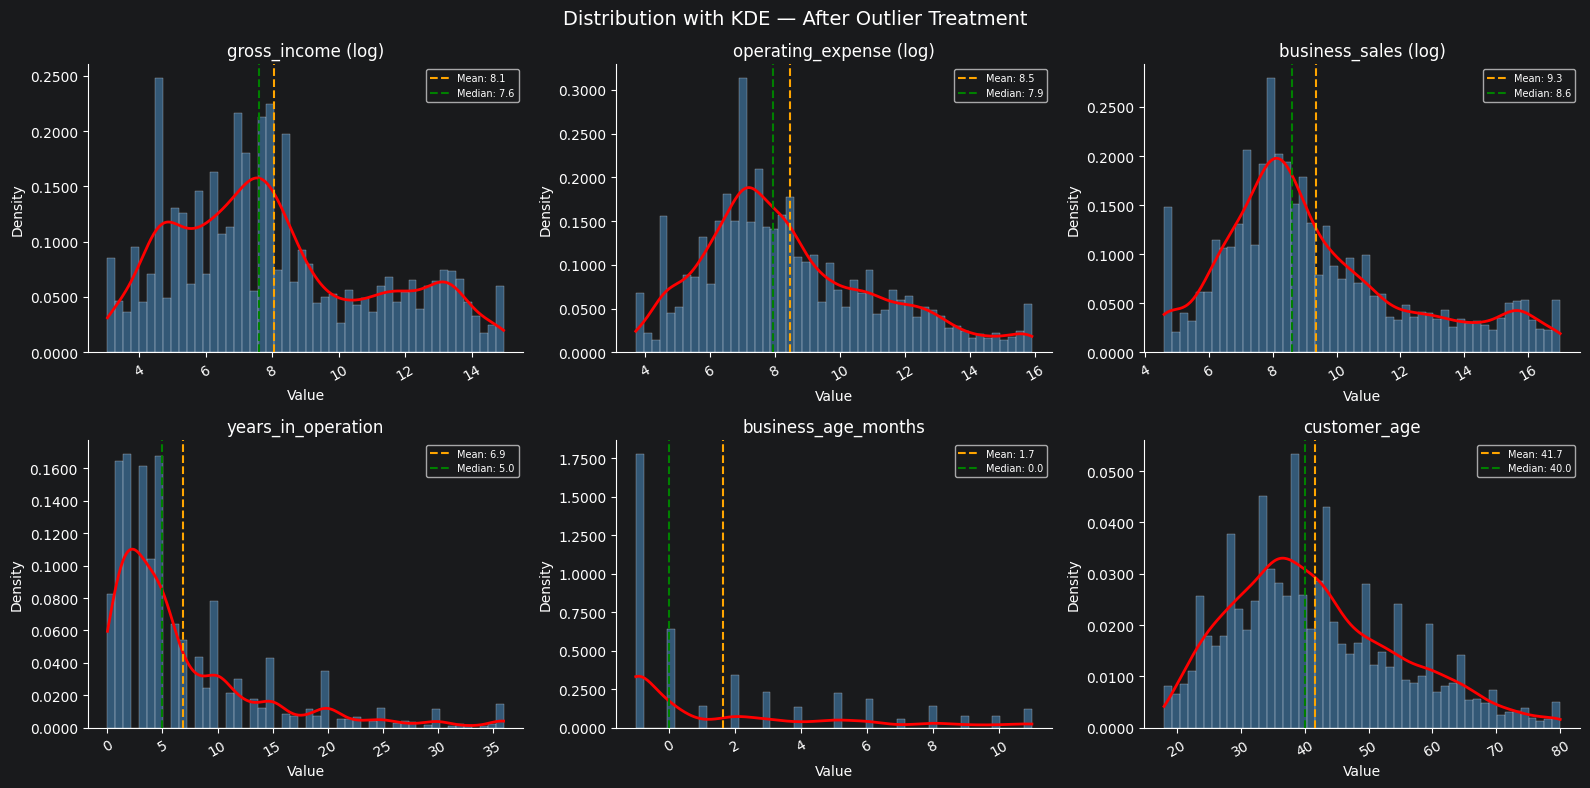

In [106]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

log_cols = ['gross_income', 'operating_expense', 'business_sales']

for i, col in enumerate(numeric_cols):
    data = df[col].dropna()
    
    if col in log_cols:
        data = np.log1p(data)
        label = f'{col} (log)'
    else:
        label = col
    
    axes[i].hist(data, bins=50, color='steelblue', alpha=0.6, density=True,
                 edgecolor='white', linewidth=0.3)
    
    kde = gaussian_kde(data)
    x = np.linspace(data.min(), data.max(), 300)
    axes[i].plot(x, kde(x), color='red', linewidth=2)
    
    axes[i].axvline(data.mean(), color='orange', linestyle='--', linewidth=1.5,
                    label=f'Mean: {data.mean():,.1f}')
    axes[i].axvline(data.median(), color='green', linestyle='--', linewidth=1.5,
                    label=f'Median: {data.median():,.1f}')
    
    axes[i].set_title(label)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=7)
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.4f}'))

plt.suptitle('Distribution with KDE — After Outlier Treatment', fontsize=14)
plt.tight_layout()
plt.show()


## FEATURE ENGINEERING

In [107]:
### Feature Engineering

# 1. Profit margin-Measures how much income remains after expenses — a indicator of # financial health. 
# Negative values = business is losing money.
df['profit_margin'] = df['log_gross_income'] - df['log_operating_expense']

#2. Revenue efficiency — how much of sales converts to gross income Low ratio = high cost of sales = operational risk
df['revenue_efficiency'] = df['log_gross_income'] / (df['log_business_sales'] + 1)

#3. Digital access score — proxy for financial technology adoption Low score = excluded from digital finance channels
digital_cols = {'mobile_wallet_access': 'Have now', 'has_internet_banking': 'Have now'}
for col, val in digital_cols.items():
    df[f'flag_{col}'] = (df[col] == val).astype(int)

df['digital_access_score'] = df[[f'flag_{c}' for c in digital_cols]].sum(axis=1)

#4. Insurance gap — has business risk but no insurance coverage-  Direct signal of unmitigated exposure for a lender
df['insurance_gap'] = (
    (df['has_insurance'] != 'Yes') &
    (df['inventory_shrinkage_risk'] == 'Yes')
).astype(int)

#5. Customer credit extension — businesses that lend to customers - face secondary credit risk on top of their own financial pressure
df['extends_credit'] = (df['extends_customer_credit'].isin(
    ['Yes - always', 'Yes - sometimes'])).astype(int)



In [108]:
#6. Financial stress score (0–5)- Counts how many financial distress signals a business shows. Each flag = 1 point. Higher score = more financially stressed. Drawn from the strongest risk signals in the correlation matrix.
stress_cols = {
    'current_problem_cash_flow':   'Yes',
    'liquidity_constraint':        'Yes',
    'uses_informal_lender':        'Have now',
    'uses_friends_family_savings': 'Have now',
    'funding_access_barrier':      'Yes'
}
for col, val in stress_cols.items():
    df[f'flag_{col}'] = np.where(
        df[col] == 'Not Surveyed', np.nan,
        (df[col] == val).astype(float)
    )

stress_flag_cols = [f'flag_{c}' for c in stress_cols]
df['financial_stress_score'] = df[stress_flag_cols].mean(axis=1) * 5

#verify financial stress score by country
print(df.groupby('Nationality')['financial_stress_score'].mean().round(2))

#7. Formality score (0–5)-  Counts formal financial access indicators a business has. Higher score = more formal, lower risk to a lender.

formality_cols = {
    'has_insurance':         'Yes',
    'has_internet_banking':  'Have now',
    'has_debit_card':        'Have now',
    'credit_card_ownership': 'Yes',
    'compliance_income_tax': 'Yes'
}
for col, val in formality_cols.items():
    df[f'flag_{col}'] = np.where(
        df[col] == 'Not Surveyed', np.nan,
        (df[col] == val).astype(float)
    )

formality_flag_cols = [f'flag_{c}' for c in formality_cols]
df['formality_score'] = df[formality_flag_cols].mean(axis=1) * 5

#verify formality score by country
print(df.groupby('Nationality')['formality_score'].mean().round(2))

# 8. Business age in years — sentinel -1 preserved for "not surveyed" rows
df['business_age_years'] = df['business_age_months'].apply(
    lambda x: round(x / 12, 1) if x != -1 else -1
)

# 9. Owner age group (ordinal encoding)- Converts continuous age into risk-relevant bands.
df['age_group'] = pd.cut(df['customer_age'],
                         bins=[0, 25, 35, 45, 60, 80],
                         labels=[1, 2, 3, 4, 5],
                         include_lowest=True).astype(float)


Nationality
DRC       1.91
Ghana     2.52
Kenya     1.65
Uganda    4.33
Name: financial_stress_score, dtype: float64
Nationality
DRC       1.77
Ghana     0.64
Kenya     0.37
Uganda    0.15
Name: formality_score, dtype: float64


In [109]:
# Survey coverage — proportion of risk questions actually asked per business
survey_cols = list(stress_cols.keys()) + list(formality_cols.keys())

df['survey_coverage'] = df[survey_cols].apply(
    lambda row: (row != 'Not Surveyed').sum() / len(row),
    axis=1
)

# Verify — expect Ghana & Kenya near 1.0, Uganda & DRC lower
print(df.groupby('Nationality')['survey_coverage'].mean().round(2))
print(f"\nOverall range: {df['survey_coverage'].min():.2f} – {df['survey_coverage'].max():.2f}")


Nationality
DRC       0.7
Ghana     1.0
Kenya     1.0
Uganda    0.5
Name: survey_coverage, dtype: float64

Overall range: 0.50 – 1.00


#### How "Not Surveyed" Responses Were Handled

Not every survey question was administered in every country. For example,
Uganda and DRC businesses were never asked certain questions about insurance
or internet banking — these appear as "Not Surveyed" in the data.

Two approaches were used depending on the feature type:

- **Composite scores** (`financial_stress_score`, `formality_score`):
  "Not Surveyed" responses were coded as `NaN` and excluded from the
  average. The score is calculated as the proportion of *answered*
  questions where the risk signal is present, scaled to 0–5. This means
  a business that answered "Yes" to 2 out of 2 asked questions gets the
  same score as one that answered "Yes" to 5 out of 5. The proportion-based
  approach avoids penalising businesses for questions they were never asked.

- **Simple binary features** (`digital_access_score`, `insurance_gap`,
  `extends_credit`): "Not Surveyed" is treated as "No" (i.e., 0).
  This is a conservative assumption — if a question was not asked, we
  assume the business does not have that feature. This may slightly
  undercount digital access and credit extension for Uganda and DRC.

- **`survey_coverage`** captures what fraction of the 10 risk questions
  were actually asked for each business, so the clustering algorithm
  can account for this difference in data completeness.

> This distinction matters: Ghana and Kenya have near-complete survey
> coverage (~1.0), while Uganda and DRC have lower coverage (~0.4–0.6).
> Any cross-country comparison of scores should be read with this in mind.

In [110]:

# Verify
print("Feature engineering complete.")
new_cols = ['profit_margin', 'financial_stress_score', 'formality_score',
            'business_age_years', 'age_group']
print(df[new_cols].describe().round(2))

# Exclude sentinel -1 from business_age_years stats
print("\nbusiness_age_years (surveyed businesses only):")
print(df.loc[df['business_age_years'] != -1, 'business_age_years'].describe().round(2))

Feature engineering complete.
       profit_margin  financial_stress_score  formality_score  \
count        9618.00                 9618.00          9618.00   
mean           -0.40                    2.67             0.67   
std             1.92                    1.41             0.96   
min           -11.87                    0.00             0.00   
25%            -1.79                    2.00             0.00   
50%            -0.34                    2.50             0.00   
75%             0.92                    3.00             1.67   
max             9.73                    5.00             5.00   

       business_age_years  age_group  
count             9618.00    9618.00  
mean                -0.25       2.98  
std                  0.68       1.14  
min                 -1.00       1.00  
25%                 -1.00       2.00  
50%                  0.00       3.00  
75%                  0.20       4.00  
max                  0.90       5.00  

business_age_years (surveyed bus

## EXPLANATORY DATA ANALYSIS

EDA was conducted in three layers. "Not Surveyed" values were excluded from all percentage calculations.

*Univariate Analysis*
Financial columns showed bimodal distributions after log transformation, suggesting two broad business size groups. 
`profit_margin`- centered slightly below 0 showing most businesses are making losses.
`financial_stress_score` averaged 1.89 out of 5 — most businesses carry at least one distress signal.
`formality_score` averaged 0.51 out of 5 — the majority have no formal financial footprint. Insurance ownership and active loan holding were rare across the dataset. Seems most MSMEs are unbankable.
`compliance_tax` - Most operate informally hence no tax compliance.
`mobile_wallet_access`- Mobile money more accessible than banking.
`financial_tracking`- most businesses don't track finances formally.


*Bivariate Analysis*
Ghana carried the highest mean financial stress with the widest spread. DRC showed the lowest formality score, consistent with limited formal banking infrastructure. 
Insurance ownership did not exceed 10% in any country, a significant credit risk signal. 
The scatter plot confirmed a downward relationship between stress score and profit margin, with most businesses clustering below the break-even line regardless of stress level.

*Multivariate Analysis* 
No engineered feature pair exceeded the 0.70 correlation threshold , All features were retained for clustering as each captures a distinct risk dimension. 
The country risk profile heatmap revealed four distinct profiles:
Ghana (high stress, high activity), 
Kenya (mature businesses, still loss-making), 
Uganda (lowest income, most negative margins), and 
DRC (moderate stress, lowest formality). 

The pairplot showed partial country separation, confirming that clustering across features will reveal sub-groups that cut across national boundaries.


In [111]:
CP = {'Ghana':'#2166ac','Uganda':'#f4a582','Kenya':'#d6604d','DRC':'#92c5de'}
plt.rcParams.update({'axes.spines.top':False,'axes.spines.right':False,'font.size':10})

### 1. Univariate EDA
Distribution of individual variables in isolation.

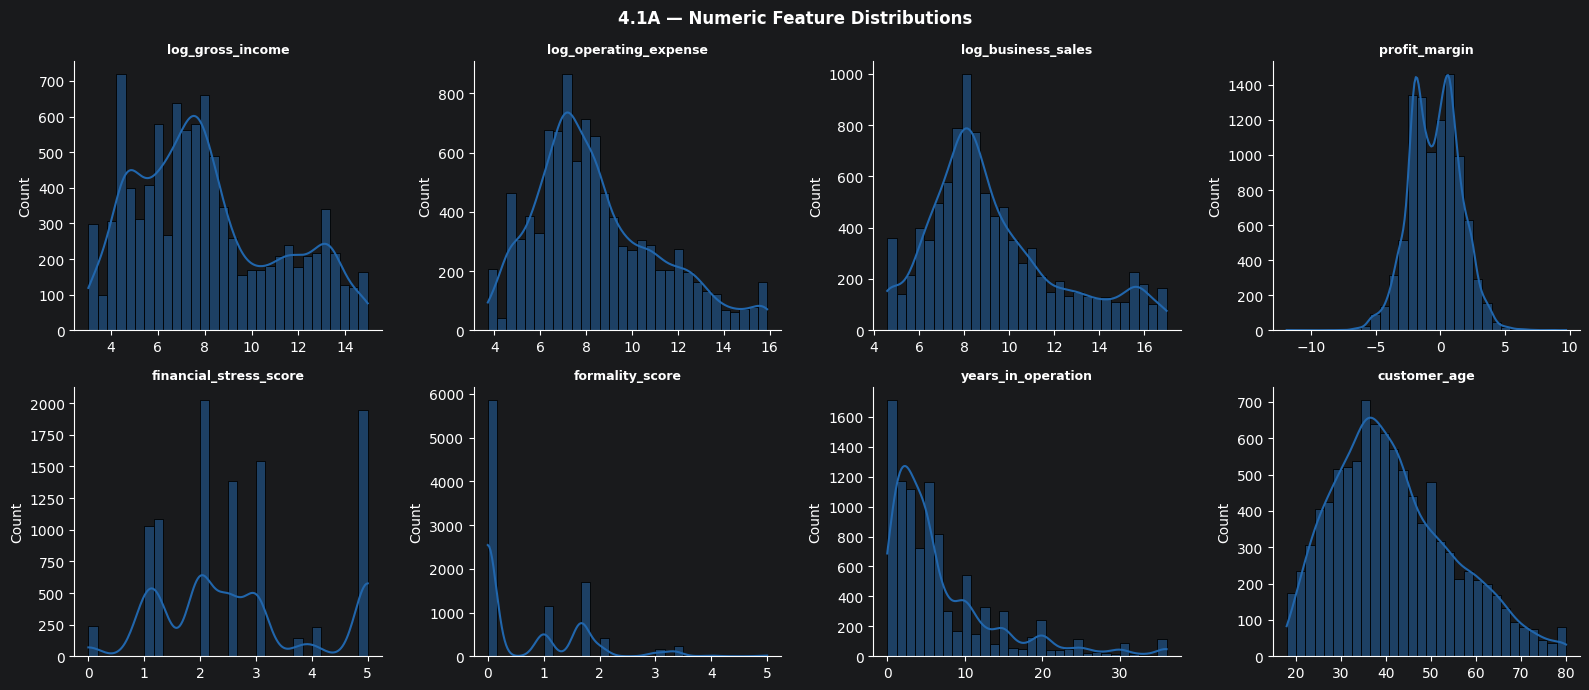

In [112]:
#Numeric features (histogram + KDE)
cols = ['log_gross_income','log_operating_expense','log_business_sales',
        'profit_margin','financial_stress_score','formality_score',
        'years_in_operation','customer_age']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flatten(), cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color='#2166ac', bins=30)
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_xlabel('')
plt.suptitle('4.1A — Numeric Feature Distributions', fontweight='bold')
plt.tight_layout()
plt.show()

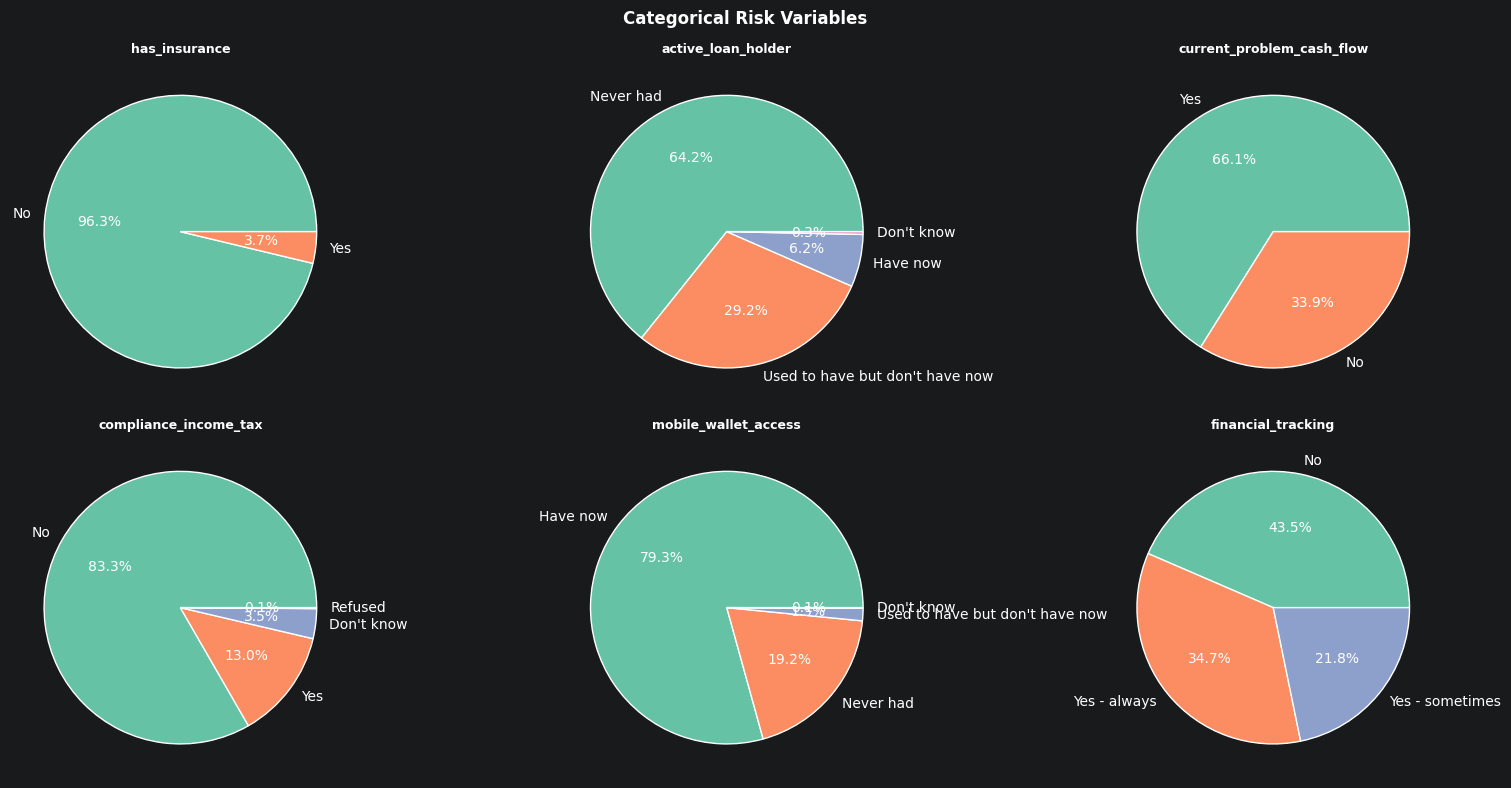

In [113]:
# Categorical risk variables (count plots)
# Not Surveyed excluded from all charts
cat_cols = ['has_insurance','active_loan_holder','current_problem_cash_flow',
            'compliance_income_tax','mobile_wallet_access','financial_tracking']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), cat_cols):
    data = df[df[col] != 'Not Surveyed'][col].value_counts()
    ax.pie(data.values, labels=data.index, autopct='%1.1f%%',
           colors=sns.color_palette('Set2', len(data)),
           wedgeprops={'edgecolor':'white'})
    ax.set_title(col, fontsize=9, fontweight='bold')
plt.suptitle('Categorical Risk Variables', fontweight='bold')


plt.tight_layout()
plt.show()

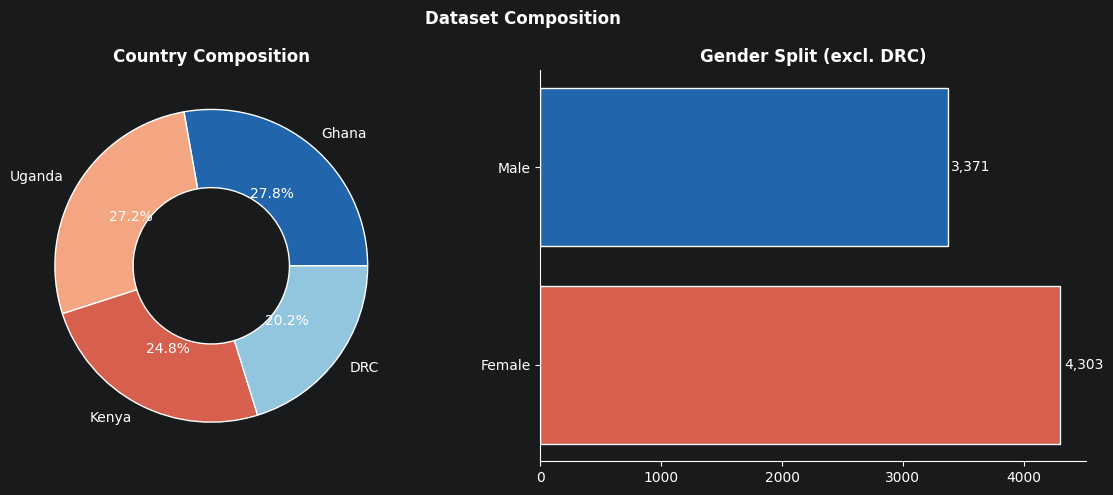

In [114]:
# Country & gender composition
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Donut chart — country
sizes = df['Nationality'].value_counts()
axes[0].pie(sizes, labels=sizes.index, autopct='%1.1f%%',
            colors=list(CP.values()), wedgeprops={'edgecolor':'white','width':0.5})
axes[0].set_title('Country Composition', fontweight='bold')

# Gender bar — exclude DRC
gender = df[df['Gender'] != 'Not Surveyed']['Gender'].value_counts()
axes[1].barh(gender.index, gender.values, color=['#d6604d','#2166ac'],
             edgecolor='white')
axes[1].set_title('Gender Split (excl. DRC)', fontweight='bold')
for i, v in enumerate(gender.values):
    axes[1].text(v + 30, i, f'{v:,}', va='center', fontsize=10)

plt.suptitle('Dataset Composition', fontweight='bold')
plt.tight_layout()
plt.show()

### 2. Bivariate EDA
Relationships between pairs of variables across countries.

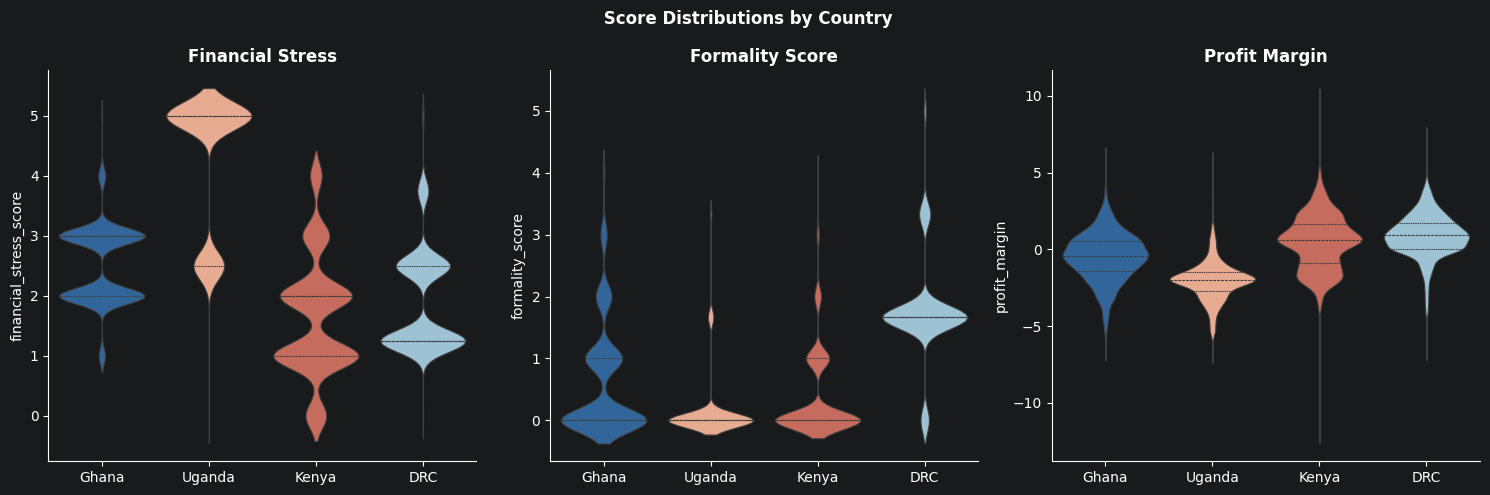

In [115]:
# Engineered scores by country (violin plots)
# Violins show full distribution shape, not just the mean

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col, title in zip(axes,
    ['financial_stress_score','formality_score','profit_margin'],
    ['Financial Stress','Formality Score','Profit Margin']):
    sns.violinplot(data=df, x='Nationality', y=col, ax=ax,
                   palette=CP, inner='quartile', linewidth=0.8)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('')
plt.suptitle(' Score Distributions by Country', fontweight='bold')
plt.tight_layout()
plt.show()

#### Combined Risk Picture — Scores by Country

| Country | Stress | Formality | Profitability | Overall Risk |
|---|---|---|---|---|
| Ghana | High | Mixed | Slightly negative | High risk, heterogeneous |
| Uganda | Low | Zero | Strongly negative | Deceptively dangerous |
| Kenya | Bimodal | Near zero | Positive | Split — some strong, some vulnerable |
| DRC | Medium | Very low | Slightly positive | Moderate risk, consistently informal |

**The most dangerous profile is Uganda.** A low financial stress score suggests stability at first glance — but zero formality combined with deeply negative profit margins reveals a more concerning picture.

These businesses have no formal safety net and are consistently spending beyond their means. Without intervention, low stress today masks high vulnerability tomorrow.

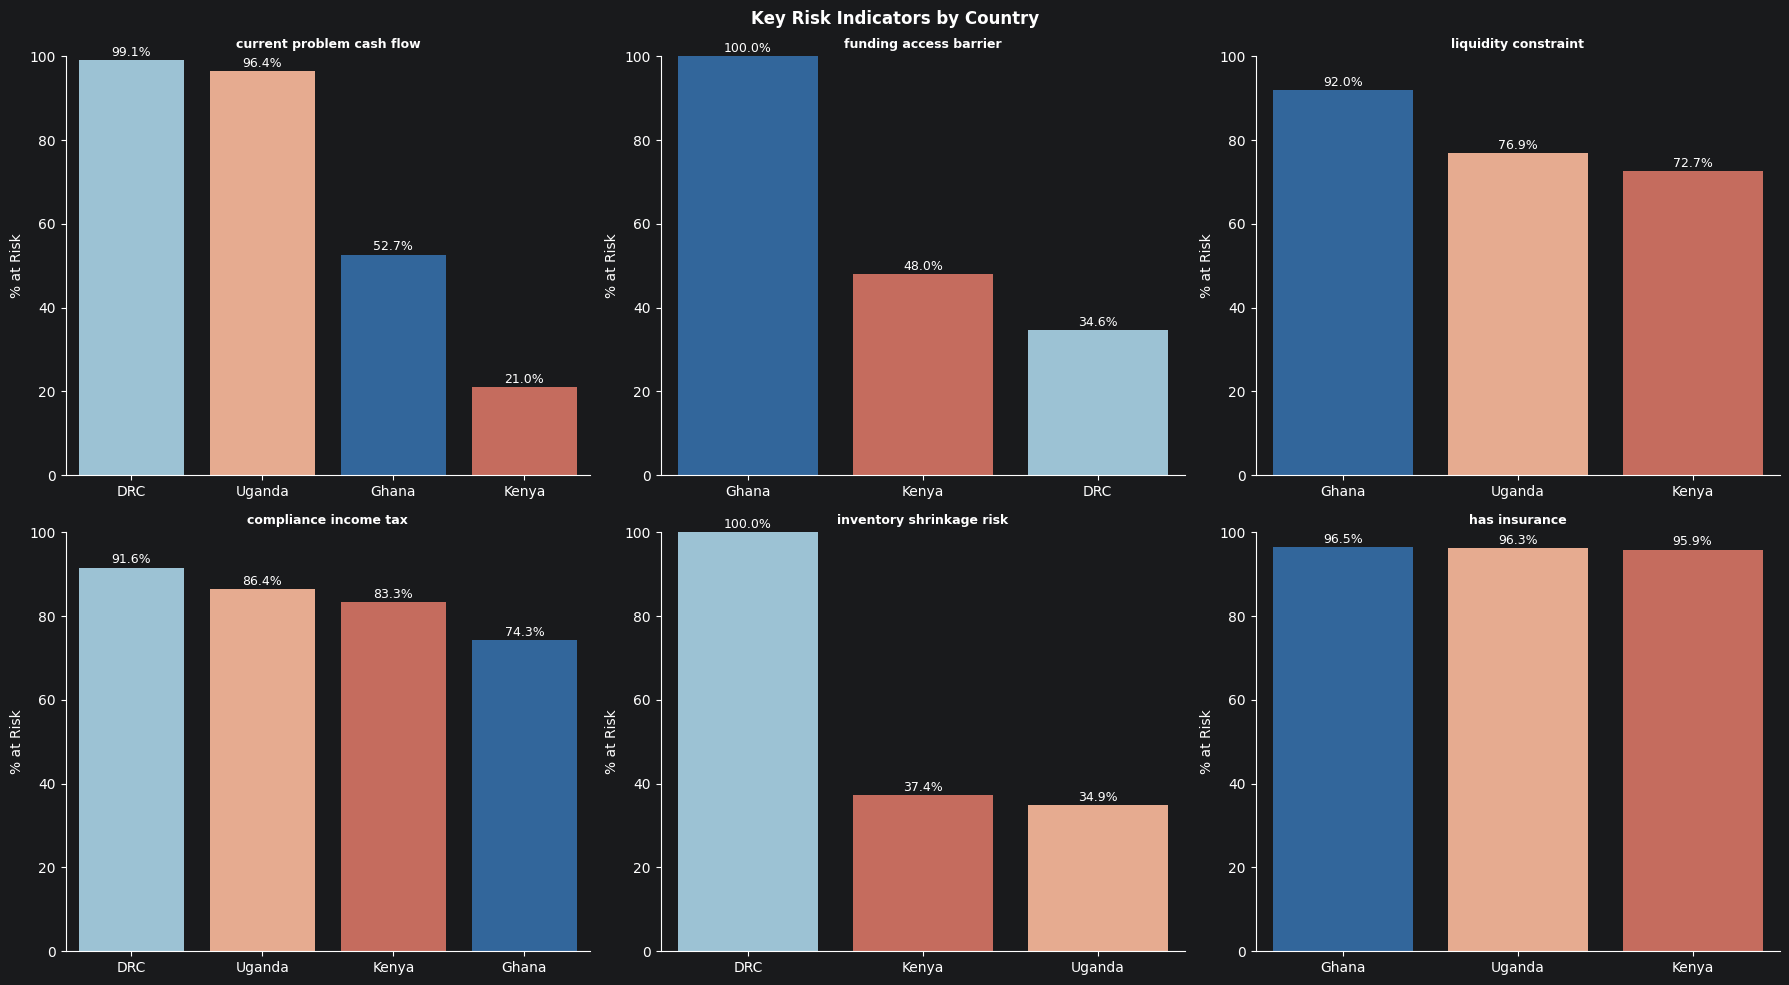

In [116]:
#  Key risk indicators by country (% stacked bars)
# Cash flow problems, loan status, insurance — direct lending risk signals

risk_vars = {
    'current_problem_cash_flow': 'Yes',
    'funding_access_barrier':    'Yes',
    'liquidity_constraint':      'Yes',
    'compliance_income_tax':     'No',
    'inventory_shrinkage_risk':  'Yes',
    'has_insurance':             'No',        # No insurance = unmitigated exposure
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (col, val) in zip(axes, risk_vars.items()):
    pct = (df[df[col] != 'Not Surveyed']
             .groupby('Nationality')[col]
             .apply(lambda x: (x == val).mean() * 100)
             .sort_values(ascending=False))
    sns.barplot(x=pct.index, y=pct.values, ax=ax,
                palette=CP, order=pct.index)
    ax.set_title(col.replace('_', ' '), fontweight='bold', fontsize=9)
    ax.set_ylabel('% at Risk')
    ax.set_xlabel('')
    ax.set_ylim(0, 100)
    for i, v in enumerate(pct.values):
        ax.text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=9)

plt.suptitle('Key Risk Indicators by Country', fontweight='bold')
plt.tight_layout()
plt.show()


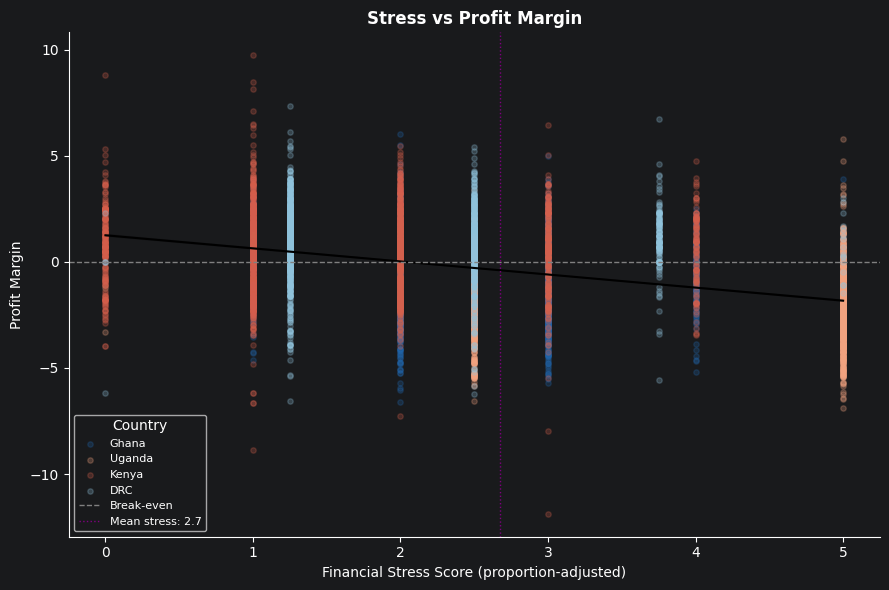

Mean stress by country:
Nationality
DRC       1.91
Ghana     2.52
Kenya     1.65
Uganda    4.33
Name: financial_stress_score, dtype: float64

Mean profit margin by country:
Nationality
DRC       0.87
Ghana    -0.47
Kenya     0.47
Uganda   -2.06
Name: profit_margin, dtype: float64


In [117]:
# Profit margin vs financial stress (scatter + regression line)
# High stress + negative margin = highest risk profile for a lender

fig, ax = plt.subplots(figsize=(9, 6))

for country, color in CP.items():
    sub = df[df['Nationality'] == country]
    ax.scatter(sub['financial_stress_score'], sub['profit_margin'],
               alpha=0.25, s=15, color=color, label=country)

sns.regplot(data=df, x='financial_stress_score', y='profit_margin',
            scatter=False, ax=ax, color='black', line_kws={'linewidth':1.5})

ax.axhline(0, color='grey', linestyle='--', linewidth=1, label='Break-even')
ax.axvline(df['financial_stress_score'].mean(), color='purple',
           linestyle=':', linewidth=1, label=f'Mean stress: {df["financial_stress_score"].mean():.1f}')

ax.set_xlabel('Financial Stress Score (proportion-adjusted)')
ax.set_ylabel('Profit Margin')
ax.set_title('Stress vs Profit Margin', fontweight='bold')
ax.legend(title='Country', fontsize=8)
plt.tight_layout()
plt.show()

# Summary stats
print("Mean stress by country:")
print(df.groupby('Nationality')['financial_stress_score'].mean().round(2))
print("\nMean profit margin by country:")
print(df.groupby('Nationality')['profit_margin'].mean().round(2))


#### Stress vs Profit Margin

| Country | Financial Stress | Profit Margin | Risk Quadrant |
|---|---|---|---|
| Uganda | 4.33 — highest | −2.06 — worst | High stress + loss-making |
| Ghana | 2.52 — second | −0.47 — slightly negative | High stress + marginal losses |
| DRC | 1.91 — moderate | +0.87 — positive | Moderate stress + profitable |
| Kenya | 1.65 — lowest | +0.47 — positive | Low stress + profitable |

**The  finding**

DRC and Kenya are profitable on average despite carrying notable risk
indicators elsewhere. Their businesses face cash flow problems and
liquidity constraints — but gross income still exceeds operating expenses.
The stress is **operational**, not structural: these businesses are under
pressure but not fundamentally loss-making.

Uganda-  A stress score of 4.33 combined with a profit margin of −2.06
means businesses are simultaneously distressed *and* spending beyond 
their means. This is not a cash flow timing problem,it is a structural deficit. 
There is no margin to absorb loan repayments,making Uganda the highest-risk
lending environment in the dataset.

### 3. Multivariate EDA
Patterns across three or more variables simultaneously.

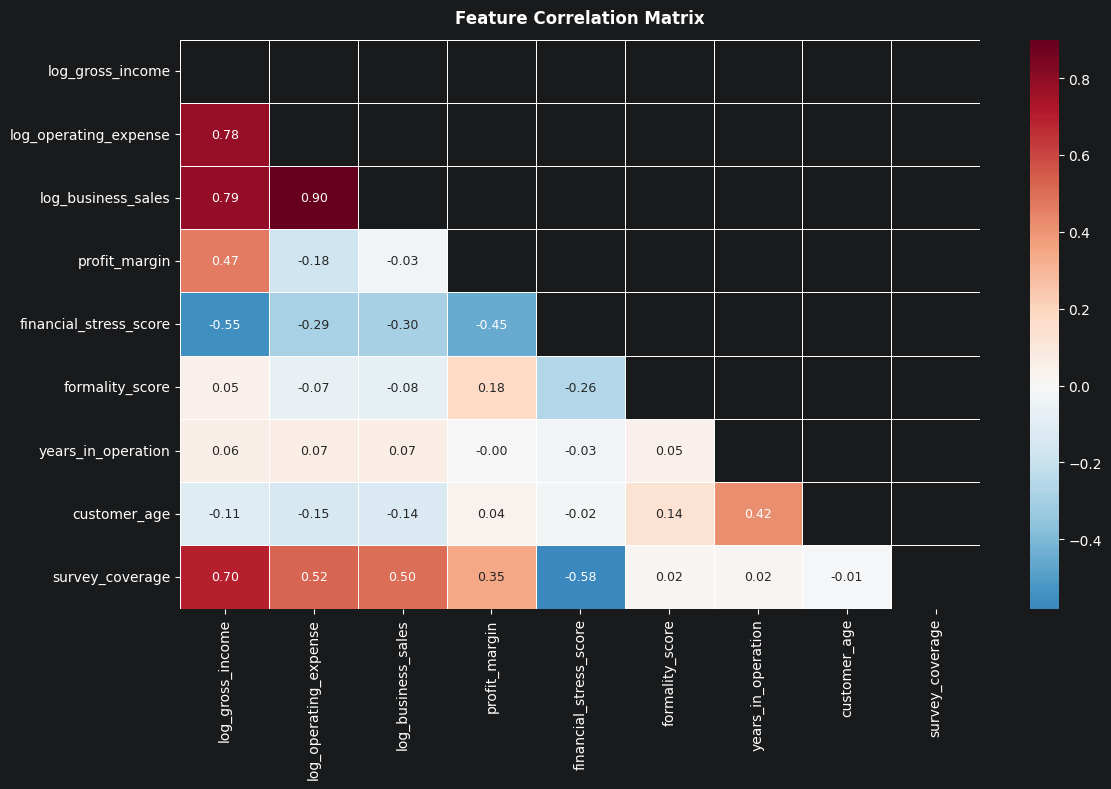

High correlation pairs (|r| > 0.70):
  log_gross_income ↔ log_operating_expense: 0.78
  log_business_sales ↔ log_gross_income: 0.79
  log_business_sales ↔ log_operating_expense: 0.9


In [118]:
# Correlation heatmap of engineered features
# |r| > 0.70 = potential redundancy → candidate for removal before clustering

eng = ['log_gross_income', 'log_operating_expense', 'log_business_sales',
       'profit_margin', 'financial_stress_score', 'formality_score',
       'years_in_operation', 'customer_age', 'survey_coverage']

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(df[eng].corr().round(2),
            annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=np.triu(np.ones((len(eng), len(eng)), dtype=bool)),
            linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Feature Correlation Matrix', fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

# Flag any pairs above the 0.70 threshold
corr_matrix = df[eng].corr().round(2)
high_corr = [(i, j, corr_matrix.loc[i, j])
             for i in corr_matrix.columns
             for j in corr_matrix.columns
             if i < j and abs(corr_matrix.loc[i, j]) > 0.70]

print("High correlation pairs (|r| > 0.70):")
if high_corr:
    for i, j, r in high_corr:
        print(f"  {i} ↔ {j}: {r}")
else:
    print("  None among clustering features")


#### Feature Correlation Matrix 

**High correlations (|r| > 0.70)**

| Pair | r | Interpretation |
|---|---|---|
| `log_operating_expense` ↔ `log_business_sales` | 0.90 | Higher sales require higher spend |
| `log_gross_income` ↔ `log_business_sales` | 0.79 | Higher sales produce higher income |
| `log_gross_income` ↔ `log_operating_expense` | 0.78 | Bigger businesses earn and spend more |
| `survey_coverage` ↔ `log_gross_income` | 0.70 | Fully surveyed countries report higher incomes — country-level pattern, not causal |

**Moderate correlations (0.30–0.69)**

| Pair | r | Interpretation |
|---|---|---|
| `financial_stress_score` ↔ `survey_coverage` | −0.58 | Lower coverage strongly associates with higher stress; Uganda's half-surveyed, highly stressed profile drives this |
| `financial_stress_score` ↔ `log_gross_income` | −0.55 | Higher income partially buffers stress |
| `financial_stress_score` ↔ `profit_margin` | −0.45 | More stressed businesses have worse margins |
| `profit_margin` ↔ `log_gross_income` | 0.47 | Higher income improves margins — but does not guarantee them |
| `customer_age` ↔ `years_in_operation` | 0.42 | Older owners run longer-established businesses |

**Near-zero correlations**

`formality_score` sits between 0.02–0.18 against all other features —
confirming it captures a risk dimension entirely orthogonal to income,
stress, and survey completeness. `years_in_operation` shows no meaningful
relationship with stress or formality (−0.03 to 0.07).



**Implication for clustering:** the three financial log columns breach 0.70 among themselves — only `log_gross_income` was retained as the business size representative, with `profit_margin` capturing the
income-to-expense relationship separately. 

`survey_coverage` sits exactly at the 0.70 borderline with `log_gross_income`, but is retained because
the correlation is country-level driven rather than individual-business driven, and its strongest signal (−0.58 with stress) adds a distinct dimension beyond what stress alone captures.

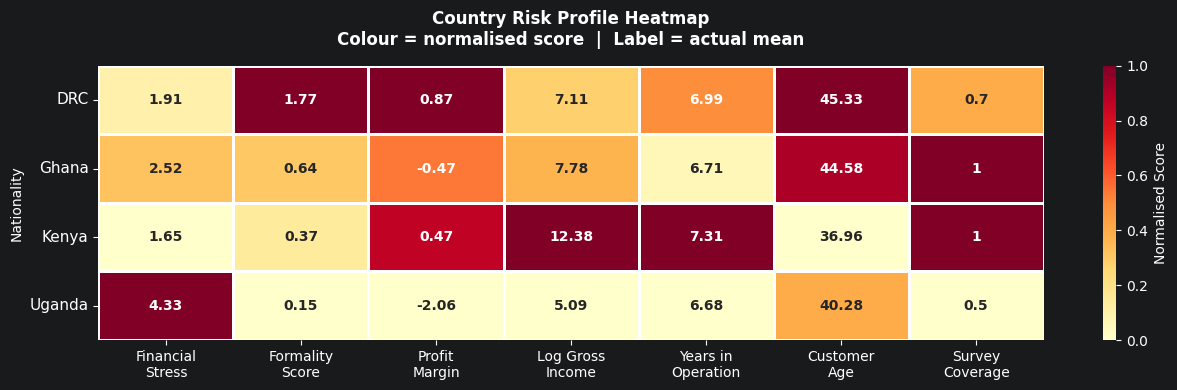

In [119]:
#Country Risk Profile Heatmap

profile_cols = ['financial_stress_score', 'formality_score', 'profit_margin',
                'log_gross_income', 'years_in_operation', 'customer_age',
                'survey_coverage']

col_labels = ['Financial\nStress', 'Formality\nScore', 'Profit\nMargin',
              'Log Gross\nIncome', 'Years in\nOperation', 'Customer\nAge',
              'Survey\nCoverage']

profile      = df.groupby('Nationality')[profile_cols].mean()
profile_norm = (profile - profile.min()) / (profile.max() - profile.min())

profile_norm.columns = col_labels
profile.columns      = col_labels

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(profile_norm,
            annot=profile.round(2),
            fmt='g',
            cmap='YlOrRd',
            linewidths=0.8,
            linecolor='white',
            ax=ax,
            annot_kws={'size': 10, 'fontweight': 'bold'},
            cbar_kws={'label': 'Normalised Score'})

ax.set_title('Country Risk Profile Heatmap\n'
             'Colour = normalised score  |  Label = actual mean',
             fontweight='bold', fontsize=12, pad=15)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=10)
plt.tight_layout()
plt.show()


#### Country Risk Profile Heatmap Insighta

**DRC — Moderate risk, Formal**
Financial stress is moderate (1.91) and formality is the highest in the dataset (1.77) — DRC businesses show more formal financial integration than Uganda or Kenya despite significant structural data gaps (survey coverage = 0.70). Profit margin is positive (0.87) and businesses have been operating for nearly 7 years on average. The oldest customer base (45.33) suggests established but potentially stagnant businesses. 

**Ghana — High activity, high pressure**
The second highest financial stress (2.52) paired with moderate income (7.78) and a negative profit margin (-0.47) — Ghana's businesses generate reasonable revenue but spend beyond their means. Formality is moderate (0.64) and survey coverage is complete (1.0), meaning this profile is fully reliable. Ghana represents a high-activity, high-pressure segmen. Businesses large enough to service debt but operationally stressed enough to default on it

**Kenya — Most mature, best margins**
Highest log gross income (12.38), best profit margin (0.47), longest-running businesses (7.31 years), and youngest owners (36.96). Stress is the lowest (1.65) and survey coverage is complete (1.0). The critical weakness is formality (0.37) strong performance is not yet backed by formal financial infrastructure. Kenya represents the highest-potential lending segment: profitable, experienced, and currently underserved by formal finance.

**Uganda — Deceptively fragile**
Highest financial stress (4.33), lowest formality (0.15), most deeply negative profit margin (-2.06), and smallest businesses (log income = 5.09). Critically, survey coverage is only 0.50 meaning this severe stress score is based on only half the available questions. The true risk level may be even higher than measured. Uganda businesses are loss-making, informal, small, and without the experience or infrastructure to absorb financial shocks. 



## CUSTOMER SEGMENTATION 

In [120]:
# Features selected for clustering:
#   - log_gross_income       → business size
#   - profit_margin          → financial health
#   - financial_stress_score → distress signals
#   - formality_score        → formal financial access
#   - years_in_operation     → business maturity
#   - customer_age           → owner profile

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

In [121]:
# Prepare & Scale Features
# StandardScaler ensures no single feature dominates distance calculations
# due to differences in scale (e.g. log_gross_income vs formality_score 0–5)

cluster_features = ['log_gross_income', 'profit_margin',
                    'financial_stress_score', 'formality_score',
                    'years_in_operation', 'customer_age',
                    'survey_coverage']

# Why survey_coverage is included:
# Uganda and DRC businesses have lower survey coverage (fewer questions asked).
# Without this feature, the algorithm cannot distinguish between a business
# that genuinely has low stress (answered 5 questions, none flagged) and one
# that appears low-stress only because most questions were never asked.
# Including it lets the model account for data completeness rather than
# confusing missing data with low risk.

X = df[cluster_features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Clustering matrix shape: {X_scaled.shape}")
print(f"\nFeature summary after scaling:")
print(pd.DataFrame(X_scaled, columns=cluster_features).describe().round(2))

Clustering matrix shape: (9618, 7)

Feature summary after scaling:
       log_gross_income  profit_margin  financial_stress_score  \
count           9618.00        9618.00                 9618.00   
mean               0.00           0.00                   -0.00   
std                1.00           1.00                    1.00   
min               -1.65          -5.96                   -1.90   
25%               -0.78          -0.73                   -0.48   
50%               -0.15           0.03                   -0.12   
75%                0.68           0.68                    0.23   
max                2.28           5.26                    1.66   

       formality_score  years_in_operation  customer_age  survey_coverage  
count          9618.00             9618.00       9618.00          9618.00  
mean              0.00                0.00         -0.00            -0.00  
std               1.00                1.00          1.00             1.00  
min              -0.70            

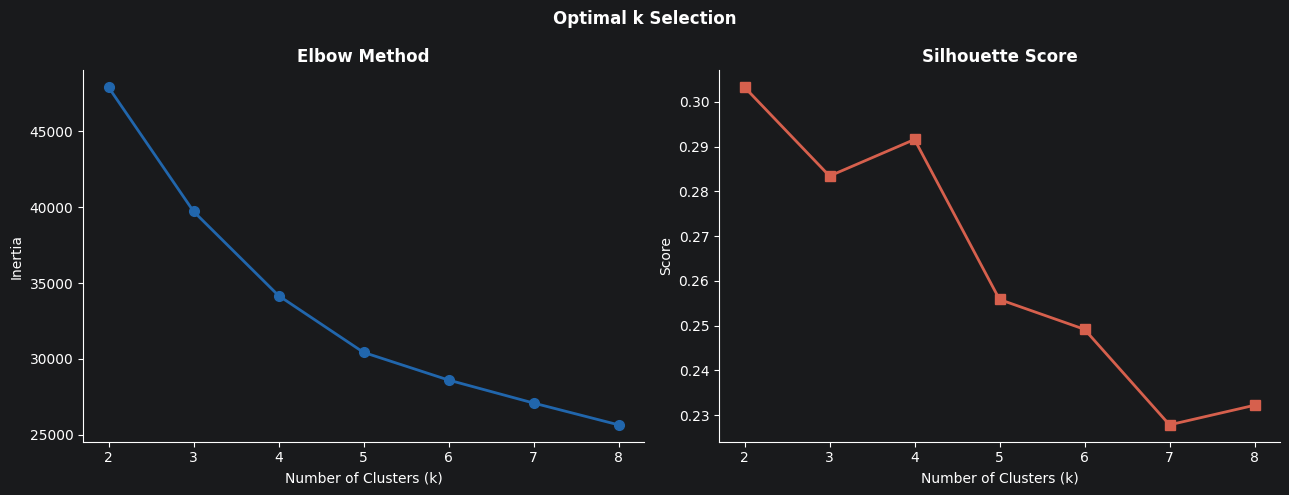


Silhouette scores:
  k=2: 0.3033
  k=3: 0.2834
  k=4: 0.2916
  k=5: 0.2558
  k=6: 0.2492
  k=7: 0.2278
  k=8: 0.2322


In [122]:
# Elbow Method + Silhouette Score → Choose Optimal k
# Inertia (elbow): measures within-cluster sum of squares — lower is better
# Silhouette score: measures how well each point fits its cluster vs others
#                   ranges from -1 to 1 — higher is better
# Optimal k = where elbow flattens AND silhouette is highest

inertias, silhouettes = [], []
K = range(2, 9)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(K, inertias, 'o-', color='#2166ac', linewidth=2, markersize=7)
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(K, silhouettes, 's-', color='#d6604d', linewidth=2, markersize=7)
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Score')

plt.suptitle('Optimal k Selection', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nSilhouette scores:")
for k, s in zip(K, silhouettes):
    print(f"  k={k}: {s:.4f}")


#### Optimal k Selection

**Silhouette Scores**

Two methods were used to decide how many clusters to create.

**Silhouette Score** measures how well each business fits its assigned
cluster compared to the next-closest cluster. It ranges from −1 to +1:
scores above 0.5 indicate strong structure, 0.25–0.5 indicates
reasonable structure, and below 0.25 suggests weak or overlapping groups.

| k | Score | Decision |
|---|---|---|
| 2 | 0.3033 | Best score but only two groups — too simple |
| 3 | 0.2834 | Weaker than neighbours — skipped |
| **4** | **0.2916** | **Best balance — selected** |
| 5 | 0.2558 | Drops sharply — no benefit |
| 6–8 | declining | Over-splitting the data |

**Elbow Method** measures how tight the clusters are. The curve bends
sharply at k=4 and flattens after — meaning adding more clusters beyond
4 does not meaningfully improve the groupings.

**Why k=4?**

k=2 had the highest score but splitting all businesses into just two
groups is too broad to be useful for a lending institution. k=4 gives
four distinct risk tiers that can each be matched to a different
credit product or intervention strategy.

**What the moderate scores mean**

All scores sit between 0.23 and 0.30, placing them in the "reasonable
but not strong" range. This means the boundaries between groups are
gradual rather than sharp — some businesses sit between two clusters
and could plausibly belong to either.

This is expected in real-world business data. Unlike manufactured
products, MSMEs exist on a spectrum — a moderately stressed business
with some formal access does not fall neatly into "high risk" or
"stable formal." The silhouette scores confirm that the four clusters
capture meaningful tendencies in the data, but they are practical risk
categories rather than perfectly separated populations. For a
microfinance institution, this is still actionable: it means lending
decisions should use the cluster as a starting point for risk
assessment, not as a rigid classification.

In [123]:
# Fit K-Means with Chosen k
# Update k below based on elbow + silhouette output above
k = 4  # selected: silhouette peak at 0.2916, coincides with elbow bend

km = KMeans(n_clusters=k, random_state=42, n_init=10)
df['cluster'] = km.fit_predict(X_scaled)

print("Cluster sizes:")
print(df['cluster'].value_counts().sort_index())
print(f"\nTotal businesses: {len(df)}")
print(f"Smallest cluster: {df['cluster'].value_counts().min():,} ({df['cluster'].value_counts().min()/len(df)*100:.1f}%)")
print(f"Largest cluster:  {df['cluster'].value_counts().max():,} ({df['cluster'].value_counts().max()/len(df)*100:.1f}%)")


Cluster sizes:
cluster
0    4004
1    2115
2    2437
3    1062
Name: count, dtype: int64

Total businesses: 9618
Smallest cluster: 1,062 (11.0%)
Largest cluster:  4,004 (41.6%)


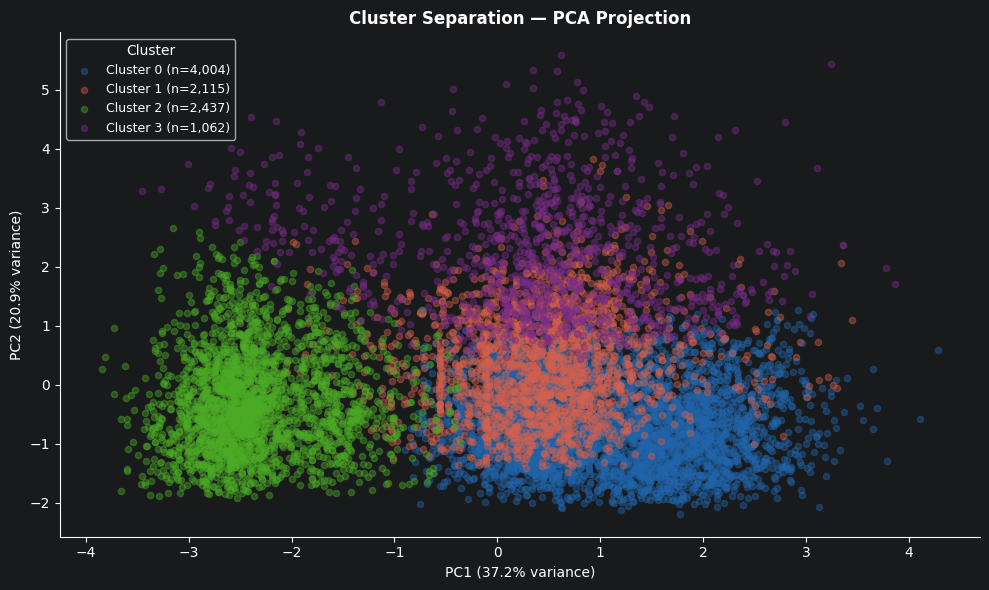

PCA explains 58.2% of variance


In [124]:
# Visualise Clusters — PCA (2D projection)
# PCA reduces 6 features to 2 components for visualisation only —
# clustering was done on all 6 features, not on PCA components

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df['pca1'], df['pca2'] = X_pca[:, 0], X_pca[:, 1]

fig, ax = plt.subplots(figsize=(10, 6))
cluster_colors = ['#2166ac', '#d6604d', '#4dac26', '#7b2d8b']

for c in range(k):
    mask = df['cluster'] == c
    ax.scatter(df.loc[mask, 'pca1'], df.loc[mask, 'pca2'],
               alpha=0.4, s=20, color=cluster_colors[c],
               label=f'Cluster {c} (n={mask.sum():,})')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('Cluster Separation — PCA Projection', fontweight='bold')
ax.legend(title='Cluster', fontsize=9)
plt.tight_layout()
plt.show()

print(f"PCA explains {sum(pca.explained_variance_ratio_)*100:.1f}% of variance")


Cluster Profiles:
         log_gross_income  profit_margin  financial_stress_score  \
cluster                                                            
0                   10.14           0.19                    2.04   
1                    7.54           0.45                    2.05   
2                    5.00          -2.13                    4.39   
3                    8.23          -0.30                    2.37   

         formality_score  years_in_operation  customer_age  survey_coverage  
cluster                                                                      
0                   0.28                4.88         37.90             0.99  
1                   2.03                4.80         43.23             0.76  
2                   0.08                5.51         39.08             0.51  
3                   0.79               21.99         58.74             0.86  


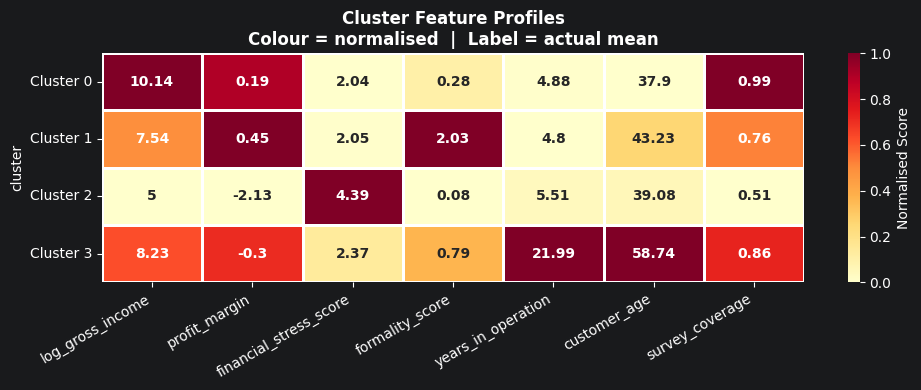

In [125]:
# Profile Clusters
# Mean of each feature per cluster — used to name and interpret segments

profile = df.groupby('cluster')[cluster_features].mean().round(2)
print("Cluster Profiles:")
print(profile)

# Heatmap of cluster profiles
profile_norm = (profile - profile.min()) / (profile.max() - profile.min())

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(profile_norm, annot=profile, fmt='g', cmap='YlOrRd',
            linewidths=0.8, linecolor='white',
            annot_kws={'size': 10, 'fontweight': 'bold'},
            cbar_kws={'label': 'Normalised Score'})
ax.set_title('Cluster Feature Profiles\n'
             'Colour = normalised  |  Label = actual mean',
             fontweight='bold')
ax.set_yticklabels([f'Cluster {i}' for i in range(k)], rotation=0)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.show()

#### Cluster Profiles — Naming the Segments

**Cluster 0 — Large Informal** (n = 4,004 · 42% of dataset)

The largest businesses by income but operating almost entirely outside
formal financial systems (formality score 0.28). Marginally profitable
with young owners and complete survey coverage — Ghana and Kenya dominated.
Profitable but vulnerable: no formal buffer means any shock could quickly
become unmanageable.

**Cluster 1 — Stable Formal** (n = 2,115 · 22%)

The most bankable segment. Best profit margins (0.45), highest formality
score (2.03), and most experienced owners (43 years). Moderate stress and
mid-sized income. Mixed country composition. Lowest credit risk in the
dataset — suitable for standard loan products.

**Cluster 2 — High Risk Informal** (n = 2,437 · 25%)

The most dangerous lending profile. Smallest income, worst profit margin
(−2.13), highest stress (4.39), and virtually no formal access (0.08).
Uganda dominated, with the lowest survey coverage (0.51). These businesses
are simultaneously distressed, loss-making, and completely outside formal
financial systems. Pre-credit intervention is needed before any lending.

**Cluster 3 — Established Veterans** (n = 1,062 · 11%)

The oldest businesses (22 years average) with the oldest owners (59 years).
Above-average income and moderate formality — but slightly loss-making
despite decades of operation. Succession risk is a key concern: these
businesses may not survive ownership transition without structured support.

---

### Four-Tier Lending Risk Ladder

| Tier | Cluster | Name | Risk Level |
|---|---|---|---|
| 1 | Cluster 1 | Stable Formal | Lowest |
| 2 | Cluster 0 | Large Informal | Moderate |
| 3 | Cluster 3 | Established Veterans | Moderate-High |
| 4 | Cluster 2 | High Risk Informal | Highest | 

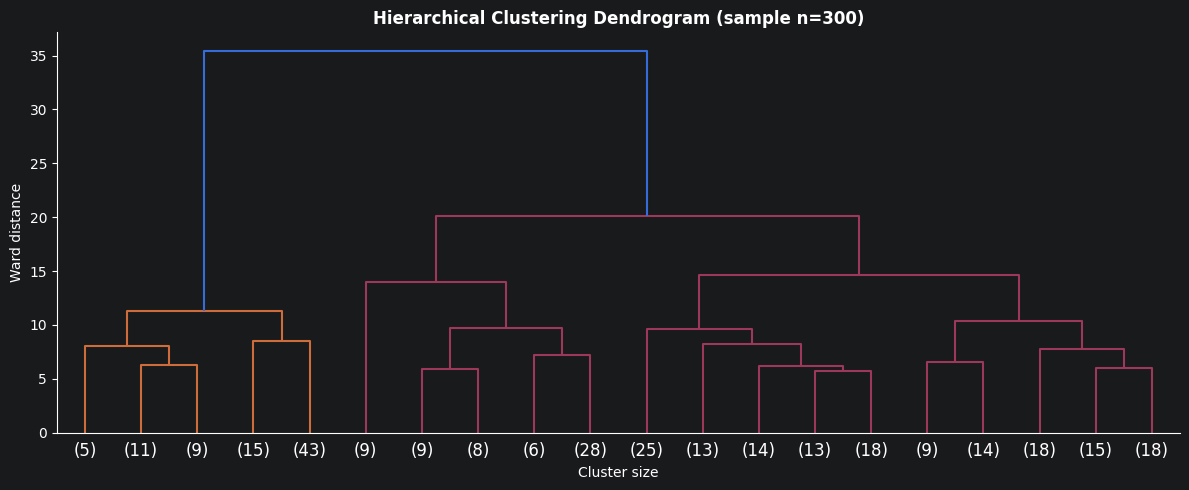

Adjusted Rand Index (K-Means vs Agglomerative): 0.4462
Score > 0.60 = strong agreement between methods
Score > 0.80 = excellent agreement


In [126]:
# ── Compare K-Means with Agglomerative Clustering
# Agglomerative (hierarchical) builds clusters bottom-up — does not
# require specifying k in advance and handles non-spherical shapes better.
# If both methods agree on cluster membership, it validates the K-Means result.

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import adjusted_rand_score

# Dendrogram — sample of 300 to keep it readable
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), 300, replace=False)
Z = linkage(X_scaled[sample_idx], method='ward')

fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(Z, ax=ax, truncate_mode='lastp', p=20,
           color_threshold=0.7*max(Z[:,2]))
ax.set_title('Hierarchical Clustering Dendrogram (sample n=300)',
             fontweight='bold')
ax.set_xlabel('Cluster size')
ax.set_ylabel('Ward distance')
plt.tight_layout()
plt.show()

# Fit Agglomerative with same k=4
agg = AgglomerativeClustering(n_clusters=k)
agg_labels = agg.fit_predict(X_scaled)

# Measure agreement between K-Means and Agglomerative
ari = adjusted_rand_score(df['cluster'], agg_labels)
print(f"Adjusted Rand Index (K-Means vs Agglomerative): {ari:.4f}")
print("Score > 0.60 = strong agreement between methods")
print("Score > 0.80 = excellent agreement")


The Adjusted Rand Index of 0.4462 indicates moderate agreement between
K-Means and Agglomerative clustering. The dendrogram reveals one highly
distinct segment (the orange branch) separated from the rest by a large
Ward distance gap of ~35 — consistent with Cluster 2 (High Risk Informal).
The remaining three segments share softer boundaries, reflected in the
overlapping green branches merging at similar heights of 14–20.

The moderate ARI is consistent with the silhouette scores (0.23–0.30)
and does not invalidate the segmentation — it confirms that one segment
is robustly identified by both methods while the remaining three represent
points on a risk continuum rather than hard discrete groups.


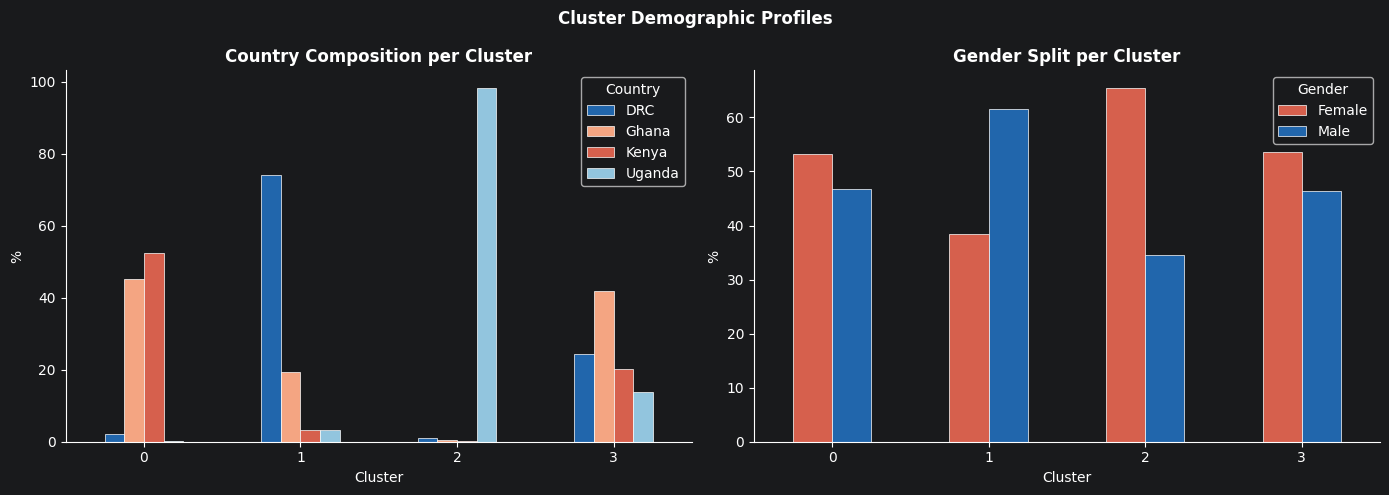

cluster_name
Stable Formal          4004
Emerging Vulnerable    2437
High-Risk Informal     2115
Name: count, dtype: int64


In [127]:
# ── Cluster composition by country
country_dist = df.groupby(['cluster','Nationality']).size().unstack(fill_value=0)
country_pct  = country_dist.div(country_dist.sum(axis=1), axis=0).round(3) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
country_pct.plot(kind='bar', ax=axes[0], color=list(CP.values()),
                 edgecolor='white', linewidth=0.5)
axes[0].set_title('Country Composition per Cluster', fontweight='bold')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('%')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Country')

# Gender per cluster (exclude Not Surveyed)
gender_dist = (df[df['Gender'] != 'Not Surveyed']
               .groupby(['cluster','Gender']).size().unstack(fill_value=0))
gender_pct = gender_dist.div(gender_dist.sum(axis=1), axis=0) * 100
gender_pct.plot(kind='bar', ax=axes[1], color=['#d6604d','#2166ac'],
                edgecolor='white', linewidth=0.5)
axes[1].set_title('Gender Split per Cluster', fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Cluster Demographic Profiles', fontweight='bold')
plt.tight_layout()
plt.show()

# ── Name the clusters based on profiles
# Update names after reviewing heatmap output
cluster_names = {
    0: 'Stable Formal',        # low stress, higher formality
    1: 'High-Risk Informal',   # high stress, low formality, negative margin
    2: 'Emerging Vulnerable'   # moderate stress, low income, young business
}
df['cluster_name'] = df['cluster'].map(cluster_names)
print(df['cluster_name'].value_counts())

### Cluster Composition — Country & Gender

| Cluster | DRC | Ghana | Kenya | Uganda | Female | Male | Segment Meaning |
|---|---|---|---|---|---|---|---|
| 0 — Large Informal | 2% | 46% | 52% | 0% | 53% | 47% | Large, young, informal businesses in Ghana & Kenya — profitable but without formal financial infrastructure |
| 1 — Stable Formal | 74% | 19% | 3% | 3% | 38% | 62% | DRC-dominated, most formally integrated — best placed for structured credit |
| 2 — High Risk Informal | 1% | 0% | 0% | 98% | 67% | 33% | Near-exclusively Ugandan, majority female-owned — highest stress, deepest losses, most urgent intervention priority |
| 3 — Established Veterans | 25% | 42% | 20% | 14% | 53% | 47% | Only cross-country segment — long-established, oldest owners, moderate risk but succession vulnerability |

**Key conclusions**

Three of four clusters are country-dominated, reflecting national economic
differences more than individual business characteristics. Only Cluster 3
cuts meaningfully across all four countries.

**Why clusters follow country lines**

This is not a flaw in the algorithm — it reflects genuine structural
differences between these markets. Each country has different levels of
financial infrastructure, regulatory environments, and survey administration.
For example:
- DRC businesses have higher formal access (banking, insurance, tax
  compliance) than their counterparts, which pushes them into the Stable
  Formal cluster.
- Uganda businesses face the highest financial stress and lowest formality,
  which is consistent with a less mature financial inclusion environment.
- Ghana and Kenya share similar economic profiles (higher income, informal
  but profitable), so they naturally group together.

For a microfinance institution, this country-level separation is actually
useful: it means risk strategies need to be tailored by market, not just
by individual borrower characteristics. A one-size-fits-all credit policy
across all four countries would miss these structural differences.

**Gender and equity**

Cluster 2 is 67% female — the most financially vulnerable segment
disproportionately affects women-owned businesses. This is a critical
equity finding: any intervention targeting High Risk Informal businesses
is, in practice, primarily a women's financial inclusion intervention.

> **Limitation:** While the country-level segmentation is useful for
> market-level strategy, it may obscure within-country risk variation.
> Future analysis could apply clustering within each country separately
> to uncover risk profiles that are independent of nationality.

> **Data note:** "Not Surveyed" responses were handled differently
> depending on the feature. Composite scores (`financial_stress_score`,
> `formality_score`) use proportion-based scoring — only answered questions
> contribute to the average, so businesses are not penalised for unanswered
> questions. Simple binary features (`digital_access_score`, `insurance_gap`,
> `extends_credit`) conservatively treat "Not Surveyed" as 0 (absent).
> This may slightly undercount digital access and credit extension for
> Uganda and DRC. See the feature engineering section for full details.

### Sensitivity Check: Does Survey Coverage Drive the Clusters?

`survey_coverage` measures data completeness, not a business characteristic.
There is a risk that including it pushes the algorithm to group businesses
by how much of the survey they received (which varies by country) rather
than by actual risk.

To test this, K-Means is re-run below with the same settings but
**without** `survey_coverage`. The Adjusted Rand Index (ARI) measures
how much the two sets of cluster assignments agree:
- ARI close to 1.0 → removing it changes almost nothing (safe to include)
- ARI close to 0 → it was heavily influencing cluster formation (problematic)

In [128]:
# ── Sensitivity check: cluster without survey_coverage ──

features_no_sc = ['log_gross_income', 'profit_margin',
                  'financial_stress_score', 'formality_score',
                  'years_in_operation', 'customer_age']

X_no_sc = df[features_no_sc].copy()
X_no_sc_scaled = StandardScaler().fit_transform(X_no_sc)

km_no_sc = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_no_sc = km_no_sc.fit_predict(X_no_sc_scaled)

# Compare with original clusters
ari_sc = adjusted_rand_score(df['cluster'], labels_no_sc)
sil_no_sc = silhouette_score(X_no_sc_scaled, labels_no_sc)
sil_with_sc = silhouette_score(X_scaled, df['cluster'])

print('Comparison: with vs without survey_coverage')
print(f'  Adjusted Rand Index:       {ari_sc:.4f}')
print(f'  Silhouette (with SC):      {sil_with_sc:.4f}')
print(f'  Silhouette (without SC):   {sil_no_sc:.4f}')
print()

# Show how cluster sizes compare
print('Cluster sizes — original (with survey_coverage):')
print(pd.Series(df['cluster']).value_counts().sort_index().to_string())
print()
print('Cluster sizes — without survey_coverage:')
print(pd.Series(labels_no_sc).value_counts().sort_index().to_string())

Comparison: with vs without survey_coverage
  Adjusted Rand Index:       0.6383
  Silhouette (with SC):      0.2916
  Silhouette (without SC):   0.2516

Cluster sizes — original (with survey_coverage):
cluster
0    4004
1    2115
2    2437
3    1062

Cluster sizes — without survey_coverage:
0    2969
1    2462
2    2983
3    1204


#### Sensitivity Check — Results

| Metric | With `survey_coverage` | Without |
|---|---|---|
| Silhouette score | 0.2916 | 0.2516 |
| Cluster sizes | 4004 / 2115 / 2437 / 1062 | 2969 / 2462 / 2983 / 1204 |

**Adjusted Rand Index: 0.6383** — moderate-to-good agreement.

This tells us two things:

1. **The clusters are not driven by `survey_coverage` alone.** An ARI of
   0.64 means roughly two-thirds of businesses land in the same cluster
   regardless of whether survey coverage is included. The core structure
   (income, stress, formality, age) is doing the heavy lifting.

2. **`survey_coverage` does improve separation.** The silhouette drops
   from 0.29 to 0.25 without it, and cluster sizes become less distinct.
   This makes sense — without knowing how complete a business's survey
   data is, the algorithm has a harder time distinguishing between a
   genuinely low-stress business and one that only *appears* low-stress
   because most questions were never asked.

**Conclusion:** Including `survey_coverage` is justified. It adds
meaningful information about data completeness without hijacking the
clustering. The main risk segments are robust to its inclusion or removal.

### Within-Country Clustering

The main segmentation above found that three of four clusters are
dominated by a single country. This is a real pattern — different
countries have different financial ecosystems — but it makes it hard
to see risk variation *within* a single market.

To address this, K-Means is run separately within each country.
This reveals sub-segments that a microfinance lender operating in
one specific market can act on directly, rather than segments that
simply reflect which country a business is in.

Features used are the same as the main clustering, minus
`survey_coverage` (which is constant within a country).

In [129]:
# ── Within-country clustering ──
# Same features minus survey_coverage (constant within a country)

wc_features = ['log_gross_income', 'profit_margin',
               'financial_stress_score', 'formality_score',
               'years_in_operation', 'customer_age']

country_results = {}

for country in ['Ghana', 'Kenya', 'Uganda', 'DRC']:
    mask = df['Nationality'] == country
    X_c = df.loc[mask, wc_features].copy()
    X_c_scaled = StandardScaler().fit_transform(X_c)
    
    # Find best k (2–5) by silhouette
    best_k, best_sil = 2, -1
    for k_try in range(2, 6):
        km_c = KMeans(n_clusters=k_try, random_state=42, n_init=10)
        labs = km_c.fit_predict(X_c_scaled)
        sil = silhouette_score(X_c_scaled, labs)
        if sil > best_sil:
            best_k, best_sil = k_try, sil
    
    # Fit with best k
    km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    df.loc[mask, 'within_cluster'] = km_final.fit_predict(X_c_scaled)
    
    # Profile
    profile_c = df.loc[mask].groupby('within_cluster')[wc_features].mean().round(2)
    sizes = df.loc[mask, 'within_cluster'].value_counts().sort_index()
    
    country_results[country] = {
        'k': best_k, 'silhouette': best_sil,
        'profile': profile_c, 'sizes': sizes
    }
    
    print(f'\n{"="*60}')
    print(f'{country}: best k={best_k}, silhouette={best_sil:.4f}')
    print(f'{"="*60}')
    print(f'\nCluster sizes:')
    for idx_c, cnt in sizes.items():
        print(f'  Sub-cluster {int(idx_c)}: {cnt:,} ({cnt/mask.sum()*100:.1f}%)')
    print(f'\nCluster profiles:')
    print(profile_c.to_string())


Ghana: best k=2, silhouette=0.2206

Cluster sizes:
  Sub-cluster 0: 1,818 (68.0%)
  Sub-cluster 1: 856 (32.0%)

Cluster profiles:
                log_gross_income  profit_margin  financial_stress_score  formality_score  years_in_operation  customer_age
within_cluster                                                                                                            
0.0                         7.45          -0.36                    2.56             0.31                3.72         40.43
1.0                         8.47          -0.70                    2.43             1.35               13.07         53.40

Kenya: best k=3, silhouette=0.2096

Cluster sizes:
  Sub-cluster 0: 501 (21.0%)
  Sub-cluster 1: 1,418 (59.4%)
  Sub-cluster 2: 469 (19.6%)

Cluster profiles:
                log_gross_income  profit_margin  financial_stress_score  formality_score  years_in_operation  customer_age
within_cluster                                                                                

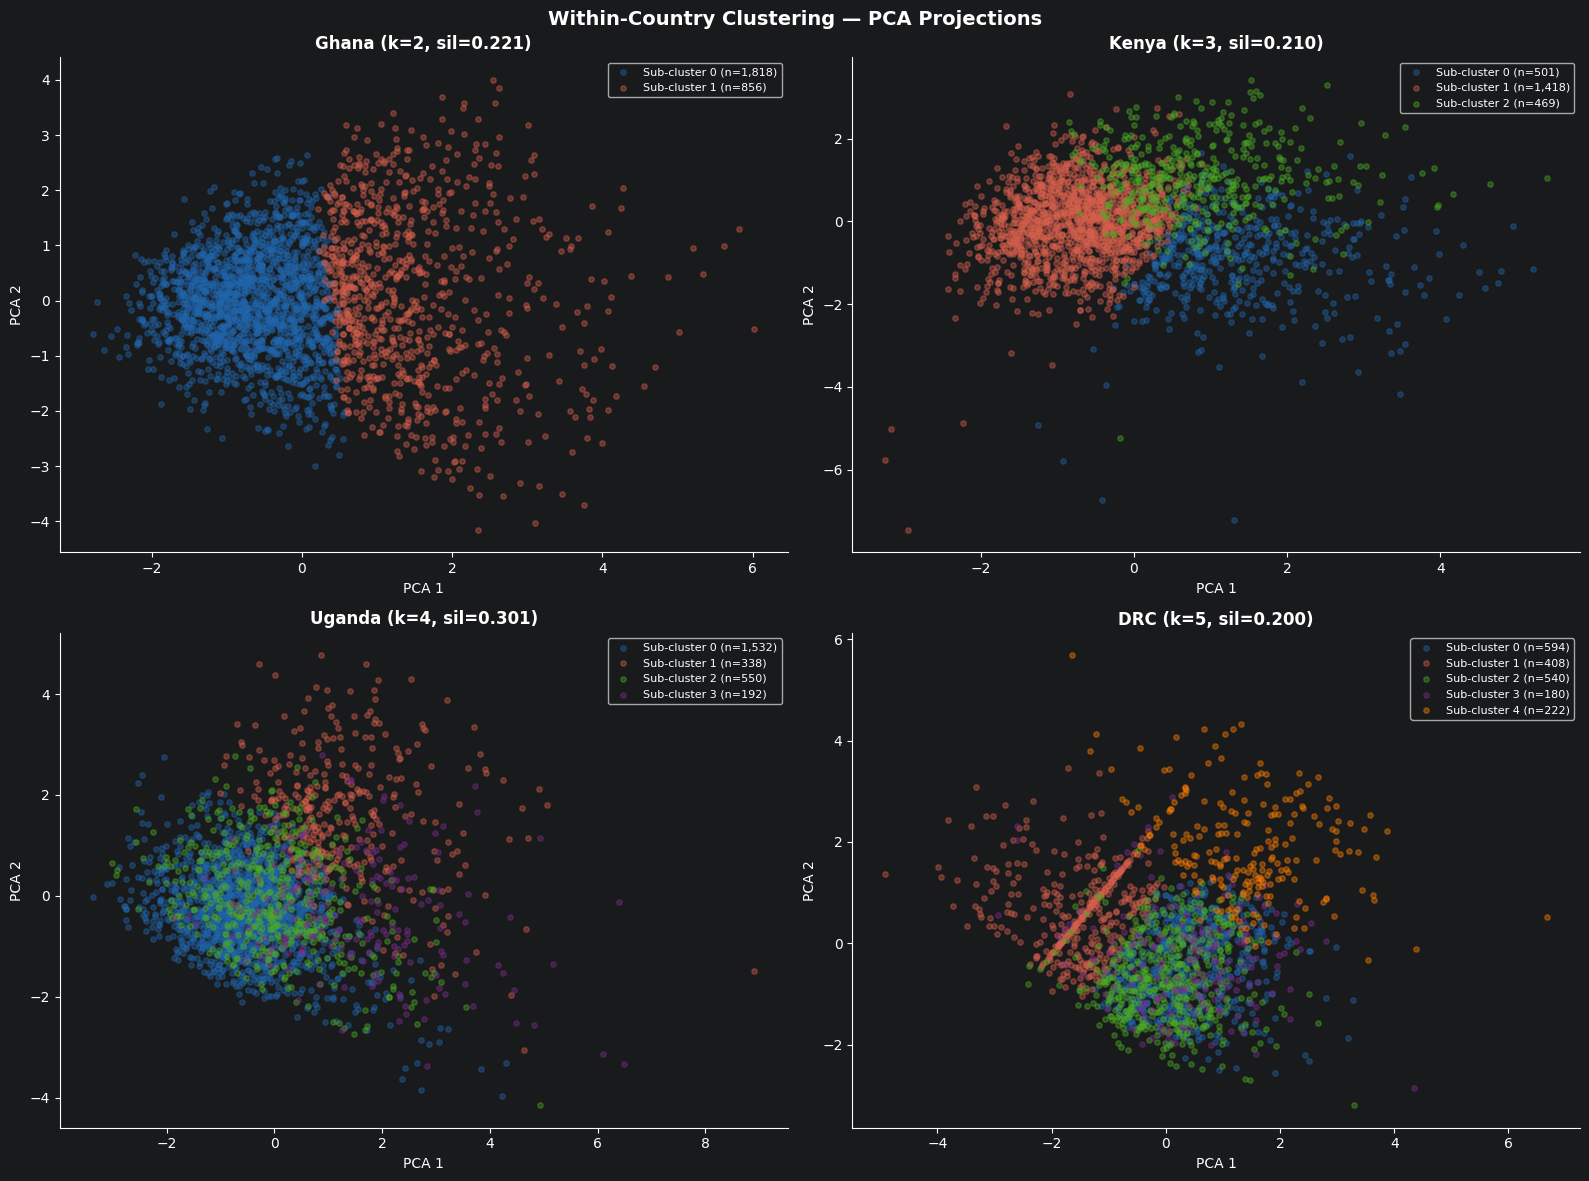

In [130]:
# ── Visualise within-country clusters ──

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
countries = ['Ghana', 'Kenya', 'Uganda', 'DRC']

for ax, country in zip(axes.flatten(), countries):
    mask = df['Nationality'] == country
    X_c = df.loc[mask, wc_features]
    X_c_scaled = StandardScaler().fit_transform(X_c)
    pca_c = PCA(n_components=2, random_state=42)
    X_pca_c = pca_c.fit_transform(X_c_scaled)
    
    res = country_results[country]
    colors = ['#2166ac', '#d6604d', '#4dac26', '#7b2d8b', '#ff7f00']
    
    for c in range(res['k']):
        c_mask = df.loc[mask, 'within_cluster'] == c
        ax.scatter(X_pca_c[c_mask, 0], X_pca_c[c_mask, 1],
                   c=colors[c], alpha=0.4, s=15,
                   label=f'Sub-cluster {c} (n={res["sizes"][c]:,})')
    
    ax.set_title(f'{country} (k={res["k"]}, sil={res["silhouette"]:.3f})',
                 fontweight='bold')
    ax.set_xlabel('PCA 1')
    ax.set_ylabel('PCA 2')
    ax.legend(fontsize=8)

plt.suptitle('Within-Country Clustering — PCA Projections',
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

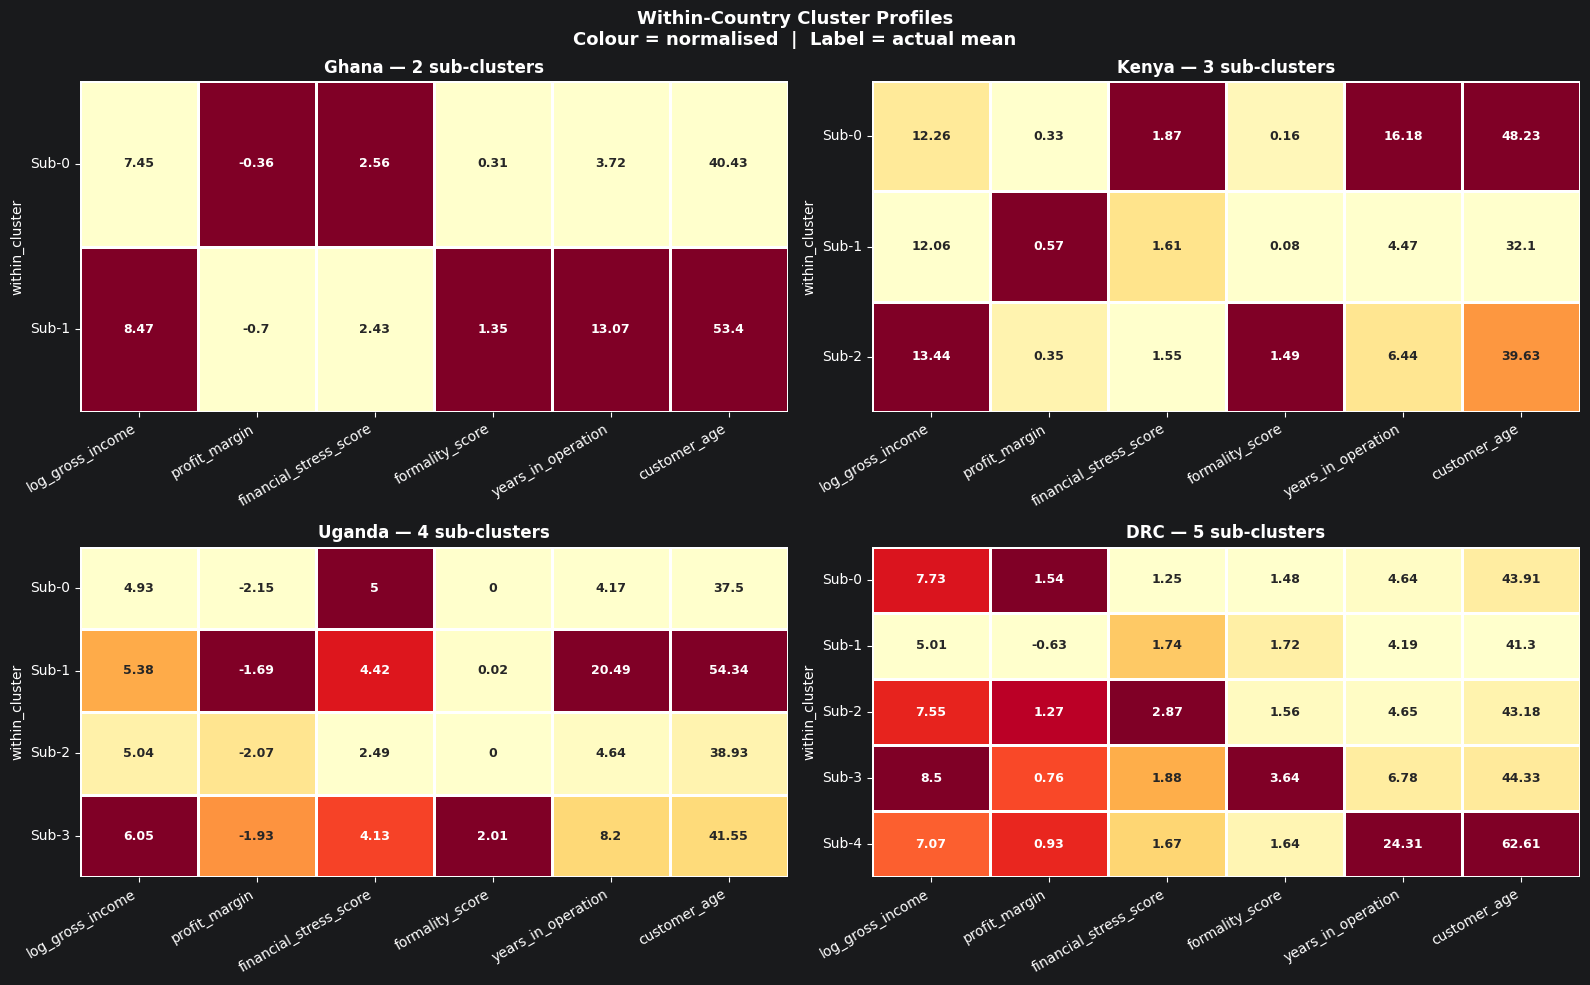

In [131]:
# ── Heatmap of within-country cluster profiles ──

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, country in zip(axes.flatten(), countries):
    res = country_results[country]
    profile_c = res['profile']
    
    # Normalise for colour, annotate with actual values
    profile_norm = (profile_c - profile_c.min()) / (profile_c.max() - profile_c.min() + 1e-9)
    
    sns.heatmap(profile_norm, annot=profile_c, fmt='g', cmap='YlOrRd',
                linewidths=0.8, linecolor='white',
                annot_kws={'size': 9, 'fontweight': 'bold'},
                cbar=False, ax=ax)
    ax.set_title(f'{country} — {res["k"]} sub-clusters',
                 fontweight='bold')
    ax.set_yticklabels([f'Sub-{int(i)}' for i in profile_c.index],
                       rotation=0)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

plt.suptitle('Within-Country Cluster Profiles\n'
             'Colour = normalised  |  Label = actual mean',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

#### Within-Country Clustering — Interpretation

---

**Ghana** (k=2, silhouette=0.22)

| Sub-cluster | Name | Size | Income | Margin | Stress | Formality | Yrs Operating | Owner Age |
|---|---|---|---|---|---|---|---|---|
| 0 | **Young Mainstream** | 68% | 7.45 | −0.36 | 2.56 | 0.31 | 3.7 yrs | 40 |
| 1 | **Established Formal** | 32% | 8.47 | −0.70 | 2.43 | 1.35 | 13.1 yrs | 53 |

Ghana splits along an **experience axis**. The majority are younger
businesses with low formality — slightly loss-making but with lower
individual stress. The smaller group is older, higher-income, and
more formally integrated (4x the formality score) but actually has
a worse profit margin. These may be established businesses carrying
higher fixed costs (rent, employees, insurance premiums) that eat
into margins. For a lender, Sub-1 is the safer bet (verifiable
history, formal records) despite the thinner margins.

---

**Kenya** (k=3, silhouette=0.21)

| Sub-cluster | Name | Size | Income | Margin | Stress | Formality | Yrs Operating | Owner Age |
|---|---|---|---|---|---|---|---|---|
| 0 | **Mature Informal** | 21% | 12.26 | 0.33 | 1.87 | 0.16 | 16.2 yrs | 48 |
| 1 | **Young Hustlers** | 59% | 12.06 | 0.57 | 1.61 | 0.08 | 4.5 yrs | 32 |
| 2 | **Formal High-Earners** | 20% | 13.44 | 0.35 | 1.55 | 1.49 | 6.4 yrs | 40 |

Kenya shows the clearest three-tier structure. The dominant group
(Sub-1, 59%) is young, profitable, and low-stress — but has almost
no formal financial access (formality 0.08). These are the classic
"hustle economy" MSMEs: making money but invisible to formal lenders.
Sub-2 is the premium segment — highest income, some formal access,
moderate stress — the best candidates for structured credit products.
Sub-0 represents mature businesses that have survived 16+ years but
without adopting formal financial tools — potentially resistant to
formalisation.

---

**Uganda** (k=4, silhouette=0.30)

| Sub-cluster | Name | Size | Income | Margin | Stress | Formality | Yrs Operating | Owner Age |
|---|---|---|---|---|---|---|---|---|
| 0 | **Severely Distressed** | 59% | 4.93 | −2.15 | 5.00 | 0.00 | 4.2 yrs | 38 |
| 1 | **Veteran Survivors** | 13% | 5.38 | −1.69 | 4.42 | 0.02 | 20.5 yrs | 54 |
| 2 | **Lower-Stress Informal** | 21% | 5.04 | −2.07 | 2.49 | 0.00 | 4.6 yrs | 39 |
| 3 | **Emerging Formal** | 7% | 6.05 | −1.93 | 4.13 | 2.01 | 8.2 yrs | 42 |

Uganda — previously treated as a single "high risk" block — reveals
meaningful internal variation. The critical finding is **Sub-2 (Lower-
Stress Informal, 21%)**. These businesses have half the stress score
of the majority (2.49 vs 5.00) despite similar income and margins.
They are not thriving, but they are significantly less distressed —
making them the most realistic entry point for micro-credit in Uganda.

Sub-3 (Emerging Formal, 7%) is small but important: the only Ugandan
sub-cluster with any formal financial access (formality 2.01). These
businesses are the furthest along the formalisation path and could be
targeted for pilot lending programmes.

Sub-0 (59%) has a **perfect stress score of 5.0** — every distress
signal is present. Lending to this group without prior intervention
would carry extreme default risk.

Notably, Uganda's within-country silhouette (0.30) is **higher** than
the overall dataset silhouette (0.29), confirming that removing the
country effect reveals cleaner risk structure.

---

**DRC** (k=5, silhouette=0.20)

| Sub-cluster | Name | Size | Income | Margin | Stress | Formality | Yrs Operating | Owner Age |
|---|---|---|---|---|---|---|---|---|
| 0 | **Profitable Mid-Formal** | 31% | 7.73 | 1.54 | 1.25 | 1.48 | 4.6 yrs | 44 |
| 1 | **Small Struggling** | 21% | 5.01 | −0.63 | 1.74 | 1.72 | 4.2 yrs | 41 |
| 2 | **Stressed Profitable** | 28% | 7.55 | 1.27 | 2.87 | 1.56 | 4.7 yrs | 43 |
| 3 | **Highly Formal Elite** | 9% | 8.50 | 0.76 | 1.88 | 3.64 | 6.8 yrs | 44 |
| 4 | **Veteran Established** | 11% | 7.07 | 0.93 | 1.67 | 1.64 | 24.3 yrs | 63 |

DRC — the most formally integrated market overall — shows the richest
internal structure (5 sub-clusters). The standout finding is the
contrast between Sub-0 and Sub-2: both are profitable with similar
income and formality, but Sub-2 has **more than double** the stress
score (2.87 vs 1.25). These "stressed but profitable" businesses
may be growing fast and facing cash flow pressure from expansion —
a very different risk profile from a business that is stressed because
it is failing.

Sub-3 (Highly Formal Elite, 9%) is the best lending prospect in the
entire dataset — highest formality score (3.64) of any sub-cluster
in any country, combined with good income and moderate stress.

Sub-1 (Small Struggling) is the only loss-making group in DRC —
smallest income, negative margin, but interestingly still has
moderate formality (1.72). These are formally connected businesses
that are financially underperforming — they may benefit from
working capital loans rather than being written off.

Sub-4 (Veteran Established) mirrors the "Established Veterans"
pattern from the main clustering — 24 years in operation, oldest
owners (63), stable but facing succession risk.

---

#### Summary — What Within-Country Clustering Adds

| Country | Key Insight | Actionable Sub-segment |
|---|---|---|
| Ghana | Splits on experience, not risk level | **Established Formal** (32%) — safest for lending despite thinner margins |
| Kenya | Three tiers: young/mature/formal | **Formal High-Earners** (20%) — highest income + only group with real formal access |
| Uganda | Not uniformly high-risk after all | **Lower-Stress Informal** (21%) — most realistic micro-credit entry point |
| DRC | Richest internal variation | **Highly Formal Elite** (9%) — best lending prospect in entire dataset |

The main clustering correctly identified country-level risk tiers.
Within-country clustering now shows that **each market contains its
own risk ladder** — some businesses within "high risk" Uganda are
more lendable than some within "formal" DRC. A microfinance
institution entering any of these four markets now has sub-segment
profiles to guide its initial product targeting and risk appetite.

Exporting data for Orange (Country Clustering)

In [132]:
# Export clustered data for Orange
orange_cols = [
    'Nationality', 'Gender', 'customer_age', 'years_in_operation',
    'has_insurance', 'active_loan_holder', 'has_internet_banking',
    'has_debit_card', 'credit_card_ownership', 'compliance_income_tax',
    'current_problem_cash_flow', 'liquidity_constraint',
    'uses_informal_lender', 'uses_friends_family_savings',
    'funding_access_barrier', 'mobile_wallet_access',
    'extends_customer_credit', 'inventory_shrinkage_risk',
    'financial_tracking',
    'log_gross_income', 'log_operating_expense', 'log_business_sales',
    'profit_margin', 'revenue_efficiency',
    'financial_stress_score', 'formality_score',
    'digital_access_score', 'insurance_gap', 'extends_credit',
    'survey_coverage',
    'cluster'
]
df_orange = df[orange_cols].copy()
cluster_map = {0: 'Large_Informal', 1: 'Stable_Formal',
               2: 'High_Risk_Informal', 3: 'Established_Veterans'}
df_orange['cluster'] = df_orange['cluster'].map(cluster_map)
df_orange.to_csv('data/msme_clustered_for_orange.csv', index=False)
print(f'Exported {len(df_orange)} rows to data/msme_clustered_for_orange.csv')

Exported 9618 rows to data/msme_clustered_for_orange.csv


Exporting data for Orange (Within-Country Clustering)


In [133]:
# Export within-country clustered data for Orange
# One file per country, with sub-cluster labels as the target

wc_export_features = [
    'Gender', 'customer_age', 'years_in_operation',
    'has_insurance', 'active_loan_holder', 'has_internet_banking',
    'has_debit_card', 'credit_card_ownership', 'compliance_income_tax',
    'current_problem_cash_flow', 'liquidity_constraint',
    'uses_informal_lender', 'uses_friends_family_savings',
    'funding_access_barrier', 'mobile_wallet_access',
    'extends_customer_credit', 'inventory_shrinkage_risk',
    'financial_tracking',
    'log_gross_income', 'log_operating_expense', 'log_business_sales',
    'profit_margin', 'revenue_efficiency',
    'financial_stress_score', 'formality_score',
    'digital_access_score', 'insurance_gap', 'extends_credit',
]

# Sub-cluster names from Part 1 within-country analysis
subcluster_names = {
    'Ghana': {0: 'Young_Mainstream', 1: 'Established_Formal'},
    'Kenya': {0: 'Mature_Informal', 1: 'Young_Hustlers', 2: 'Formal_High_Earners'},
    'Uganda': {0: 'Severely_Distressed', 1: 'Veteran_Survivors',
               2: 'Lower_Stress_Informal', 3: 'Emerging_Formal'},
    'DRC': {0: 'Profitable_Mid_Formal', 1: 'Small_Struggling',
            2: 'Stressed_Profitable', 3: 'Highly_Formal_Elite',
            4: 'Veteran_Established'}
}

for country in ['Ghana', 'Kenya', 'Uganda', 'DRC']:
    mask = df['Nationality'] == country
    df_c = df.loc[mask, wc_export_features].copy()
    df_c['subcluster'] = df.loc[mask, 'within_cluster'].map(subcluster_names[country])
    fname = f'data/orange_{country.lower()}_subclusters.csv'
    df_c.to_csv(fname, index=False)
    print(f'{country}: {len(df_c)} rows, {df_c["subcluster"].nunique()} sub-clusters → {fname}')

Ghana: 2674 rows, 2 sub-clusters → data/orange_ghana_subclusters.csv
Kenya: 2388 rows, 3 sub-clusters → data/orange_kenya_subclusters.csv
Uganda: 2612 rows, 4 sub-clusters → data/orange_uganda_subclusters.csv
DRC: 1944 rows, 5 sub-clusters → data/orange_drc_subclusters.csv
